In [1]:
import os
import caesar
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import modules as anal
import modules.anal_func as anal_func

from astropy.cosmology import LambdaCDM
import astropy.units as u
from astropy.io import fits
from scipy import interpolate

from modules.anal_func.build_history import BuildHistory
from modules.anal_func.read_progenitors import read_progen

from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np


cosmo = LambdaCDM(H0 = 68, Om0= 0.3, Ode0= 0.7, Ob0=0.048)
plt.rcParams.update({'font.size': 28})

In [2]:
# initialize the Simba class, which import the needed paths
sb = anal.Simba('PC39BP4', size=100)
# initialize the SavePaths class to create destinations
sv = anal.SavePaths() 
pltsv  = sv.get_filetype_path('plot')
scatter = sv.create_subdir(pltsv, 'scatter')

In [3]:
cs = sb.get_caesar(150)
totids = np.asarray([i.GroupID for i in cs.galaxies])
sfh = BuildHistory(sb, '/home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5', progfilename='progenitors_most_mass_nocaesar.fits')

yt : [INFO     ] 2025-06-04 17:14:24,143 Opening /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_150.hdf5
yt : [INFO     ] 2025-06-04 17:14:24,160 Found 465211 halos
yt : [INFO     ] 2025-06-04 17:14:24,163 Found 55336 galaxies


In [4]:
hist = sfh.get_history_indx(totids[:55000], start_snap=44, end_snap=149)

In [ ]:
sfr = sfh.get_property_history([ 'stellar_masses', 'sfr', 'dust_masses', 'H2_masses', 'mass_weighted_ages', 'GroupID'])

Number of snapshots: 106
Opening /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_044.fits
Opening /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_045.fits
Opening /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_046.fits
Opening /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_047.fits
Opening /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_048.fits
Opening /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_049.fits
Opening /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_050.fits
Opening /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_051.fits
Opening /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_052.fits
Opening /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_053.fits
Opening /home/lorenzong/analize_simba_cgm/out

In [6]:
# define our redshift range
z = sb.get_z_from_snap(np.arange(44, 150, 1))
tcosmo = cosmo.age(z).value

In [7]:
indx = -16
print('z = ', z[indx])
print(np.log10(0.2/cosmo.age(z[indx]).to(u.yr).value), 'Gyr')

z =  0.30543190214482463
-10.711506586401068 Gyr


In [8]:
# Stellar mass selection
logM = np.log10(sfr['stellar_masses'][indx, :])
Ms_cut = logM > 9.8
Age_cut = np.log10(sfr['mass_weighted_ages'][indx, :]*1e9) > 9.4

# Specific SFR selection
ssfr = np.log10(sfr['sfr'][indx, :] / sfr['stellar_masses'][indx, :])
ssfr_cut = ssfr < np.log10(0.2/cosmo.age(z[indx]).to(u.yr).value)

# Combined cut (boolean mask)
combined_cut = np.all([Ms_cut , ssfr_cut, Age_cut], axis=0)

# If you want the indices of the galaxies that satisfy both:
galaxy_selection = np.where(combined_cut)[0]


print(f"Number of galaxies selected: {len(galaxy_selection)} over {len(sfr['stellar_masses'][indx, :])} total galaxies.")


Number of galaxies selected: 8094 over 55000 total galaxies.


/tmp/ipykernel_199141/415882845.py:7: RuntimeWarning: divide by zero encountered in log10
  ssfr = np.log10(sfr['sfr'][indx, :] / sfr['stellar_masses'][indx, :])


/tmp/ipykernel_159580/748414016.py:1: RuntimeWarning: divide by zero encountered in log10
  plt.hist(np.log10((sfr['sfr']/ sfr['stellar_masses']))[indx,:], bins=100, range=(-15, -8), histtype='step', lw=2)
/tmp/ipykernel_159580/748414016.py:2: RuntimeWarning: divide by zero encountered in log10
  plt.hist(np.log10((sfr['sfr']/ sfr['stellar_masses']))[indx,galaxy_selection.astype(int)], bins=100, range=(-15, -8), histtype='step', lw=2)
/tmp/ipykernel_159580/748414016.py:3: RuntimeWarning: divide by zero encountered in log10
  plt.hist(np.log10((sfr['sfr']/ sfr['stellar_masses']))[-15,galaxy_selection.astype(int)], bins=100, range=(-15, -8), histtype='step', lw=2)
/tmp/ipykernel_159580/748414016.py:4: RuntimeWarning: divide by zero encountered in log10
  plt.hist(np.log10((sfr['sfr']/ sfr['stellar_masses']))[-10,galaxy_selection.astype(int)], bins=100, range=(-15, -8), histtype='step', lw=2)
/tmp/ipykernel_159580/748414016.py:5: RuntimeWarning: divide by zero encountered in log10
  plt.h

(array([  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   5.,   0.,   2.,   1.,
          2.,   0.,   7.,   2.,   6.,   6.,  16.,  66.,   7.,  15.,  20.,
         26.,  37.,  47.,  56.,  58.,  66.,  55.,  78.,  68.,  88.,  97.,
         86., 110., 152., 141., 159., 143., 149., 148., 157., 135., 149.,
        136., 115., 122.,  88.,  81.,  82.,  53.,  51.,  41.,  20.,  17.,
         18.,  15.,  12.,   6.,   9.,   6.,   4.,   4.,   3.,   4.,   6.,
          0.,   1.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.]),
 array([-15.        , -14.93000031, -14.85999966, -14.78999996,
        -14.72000027, -14.64999962, -14.57999992, -14.51000023,
        -14.43999958, -14.36999989, -14.30000019, -14.22999954,
        -14.15999985, -14.09000015, -14.02000046, -13.94999981,
        -13.88000011, -13.81000042, -13.73999977, -13.67000008

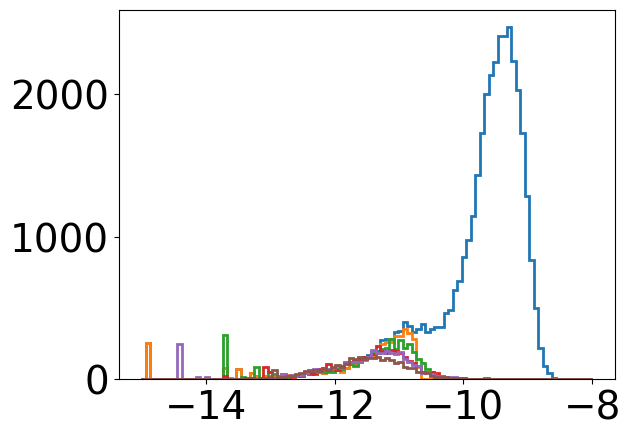

In [154]:
plt.hist(np.log10((sfr['sfr']/ sfr['stellar_masses']))[indx,:], bins=100, range=(-15, -8), histtype='step', lw=2)
plt.hist(np.log10((sfr['sfr']/ sfr['stellar_masses']))[indx,galaxy_selection.astype(int)], bins=100, range=(-15, -8), histtype='step', lw=2)
plt.hist(np.log10((sfr['sfr']/ sfr['stellar_masses']))[-15,galaxy_selection.astype(int)], bins=100, range=(-15, -8), histtype='step', lw=2)
plt.hist(np.log10((sfr['sfr']/ sfr['stellar_masses']))[-10,galaxy_selection.astype(int)], bins=100, range=(-15, -8), histtype='step', lw=2)
plt.hist(np.log10((sfr['sfr']/ sfr['stellar_masses']))[-8,galaxy_selection.astype(int)], bins=100, range=(-15, -8), histtype='step', lw=2)
plt.hist(np.log10((sfr['sfr']/ sfr['stellar_masses']))[-3,galaxy_selection.astype(int)], bins=100, range=(-15, -8), histtype='step', lw=2)

(array([  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,  98.,
        206., 328., 545., 559., 554., 465., 456., 377., 370., 306., 306.,
        358., 237., 208., 251., 176., 183., 188., 132., 178., 132.,  92.,
        116., 205., 105.,  97., 102., 115., 137., 112.,  45.,  44.,  35.,
          0.,  37.,   0.,   0.,   0., 254.,   0.,   0.,   0.,   0.,   0.,
          0.]),
 array([ 6.        ,  6.07000017,  6.13999987,  6.21000004,  6.28000021,
         6.3499999 ,  6.42000008,  6.48999977,  6.55999994,  6.63000011,
         6.69999981,  6.76999998,  6.84000015,  6.90999985,  6.98000002,
         7.05000019,  7.11999989,  7.19000006,  7.26000023,  7.32999992,
         7.4000001 ,  7.46

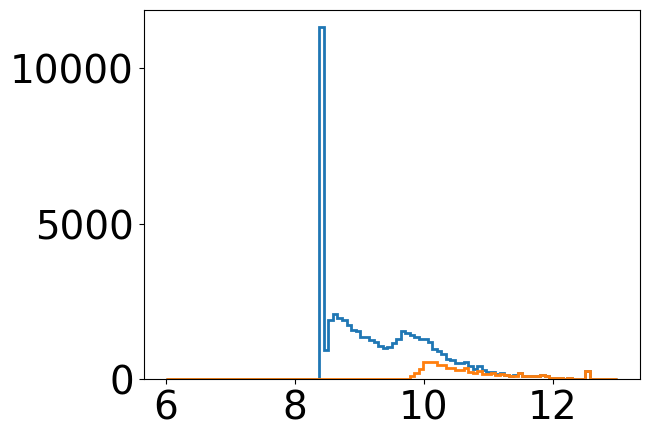

In [155]:
plt.hist(np.log10(sfr['stellar_masses'])[indx,:], bins=100, range=(6, 13), histtype='step', lw=2)
plt.hist(np.log10(sfr['stellar_masses'])[indx,galaxy_selection.astype(int)], bins=100, range=(6, 13), histtype='step', lw=2)

(array([  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,  13.,  34.,  41.,
         52.,  75.,  74.,  59.,  84.,  79., 107., 116., 125., 129., 155.,
        161., 154., 183., 179., 182., 228., 223., 233., 263., 215., 249.,
        241., 254., 250., 236., 232., 254., 238., 191., 237., 306., 259.,
        300., 375., 206., 183., 141., 123., 130., 389.,  47.,  57.,  22.,
         14.,   3.,   4.,   1.,   2.,   1.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.]),
 array([ 0.        ,  0.13      ,  0.25999999,  0.38999999,  0.51999998,
         0.64999998,  0.77999997,  0.91000003,  1.03999996,  1.16999996,
         1.29999995,  1.42999995,  1.55999994,  1.69000006,  1.82000005,
         1.95000005,  2.07999992,  2.21000004,  2.33999991,  2.47000003,
         2.5999999 ,  2.73

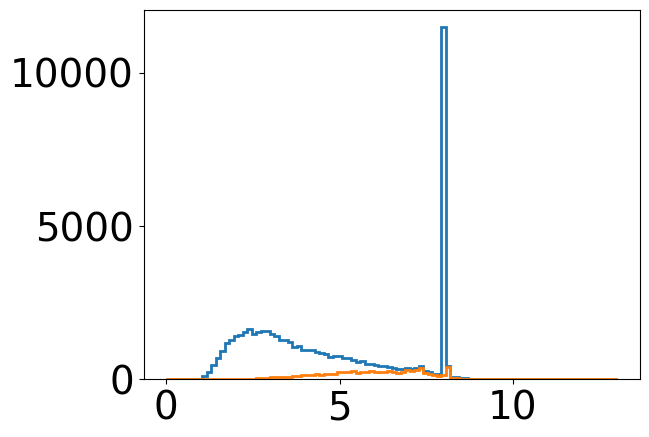

In [156]:
plt.hist(sfr['mass_weighted_ages'][indx,:], bins=100, range=(0, 13), histtype='step', lw=2)
plt.hist(sfr['mass_weighted_ages'][indx,galaxy_selection.astype(int)], bins=100, range=(0, 13), histtype='step', lw=2)

407


/tmp/ipykernel_159580/281277524.py:1: RuntimeWarning: divide by zero encountered in log10
  plt.hist(np.log10(sfr['dust_masses'][indx,:]/sfr['stellar_masses'][indx,:]), bins=100, range=(-10, -1), histtype='step', lw=2)
/tmp/ipykernel_159580/281277524.py:2: RuntimeWarning: divide by zero encountered in log10
  plt.hist(np.log10(sfr['dust_masses'][indx,galaxy_selection.astype(int)]/sfr['stellar_masses'][indx,galaxy_selection.astype(int)]), bins=100, range=(-10, -1), histtype='step', lw=2)
/tmp/ipykernel_159580/281277524.py:3: RuntimeWarning: divide by zero encountered in log10
  print(len(np.log10(sfr['dust_masses'][indx,galaxy_selection.astype(int)]/sfr['stellar_masses'][indx,galaxy_selection.astype(int)])[np.log10(sfr['dust_masses'][indx,galaxy_selection.astype(int)]/sfr['stellar_masses'][indx,galaxy_selection.astype(int)]) > -4]))


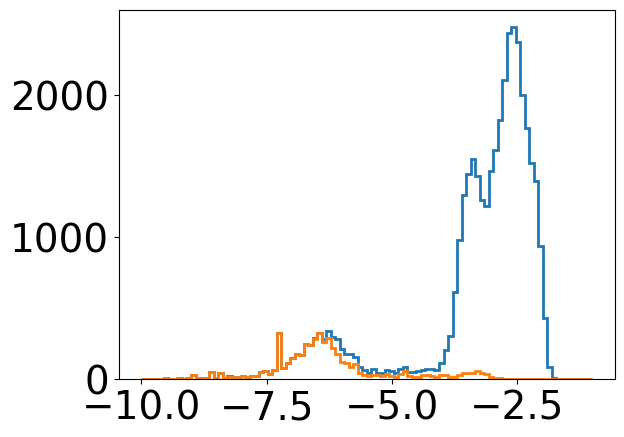

In [157]:
plt.hist(np.log10(sfr['dust_masses'][indx,:]/sfr['stellar_masses'][indx,:]), bins=100, range=(-10, -1), histtype='step', lw=2)
plt.hist(np.log10(sfr['dust_masses'][indx,galaxy_selection.astype(int)]/sfr['stellar_masses'][indx,galaxy_selection.astype(int)]), bins=100, range=(-10, -1), histtype='step', lw=2)
print(len(np.log10(sfr['dust_masses'][indx,galaxy_selection.astype(int)]/sfr['stellar_masses'][indx,galaxy_selection.astype(int)])[np.log10(sfr['dust_masses'][indx,galaxy_selection.astype(int)]/sfr['stellar_masses'][indx,galaxy_selection.astype(int)]) > -4]))

In [8]:
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.interpolate import InterpolatedUnivariateSpline
from astropy.cosmology import Planck15 as cosmo
import astropy.units as u
from tqdm import tqdm




def findQT(tarr, ssfr, plot = False):
    tau = np.log10(0.2/(tarr))
    diff = ssfr - tau

    intersectionD = np.array([])
    intersectionU = np.array([])
    for i in range(len(ssfr)-1):
        if diff[i]*diff[i+1] < 0:
            if diff[i] > diff[i+1]:
                intersectionD = np.append(intersectionD, [tarr[i]])
            else:
                intersectionU = np.append(intersectionU, [tarr[i]])

    intersectionU = np.append(intersectionU, [tarr[-1]])
    for i in range(len(intersectionD)):
        if intersectionU[i] - intersectionD[i] > 0.2*intersectionD[i] or intersectionU[i] == tarr[-1]:
            QT = intersectionD[i]
            break


    tau = np.log10(1/(tarr))
    diff = ssfr - tau
    for i in range(len(ssfr) - 1):
        if tarr[i]<QT and diff[i] * diff[i + 1] < 0:
            SFRT = tarr[i]

    return QT, SFRT


def quenching_info(sfh, z, znow=None, Npoints=1000, ID=None, output_file=None, plot=False, verbose=0, sv=None):
    def process_single_galaxy(sfh, z, galaxy_id):
        sfh_gal = np.array(sfh[:, galaxy_id])
        if len(z) < 3:
            if verbose:
                print(f"Galaxy {galaxy_id}: Not enough snapshots.")
            return np.nan, np.nan, np.nan

        z_dense = np.linspace(z.min(), z.max(), Npoints)
        t_dense = cosmo.age(z_dense).to(u.yr).value


        t_sfh = cosmo.age(z).to(u.yr).value
        sfh_interp = InterpolatedUnivariateSpline(t_sfh, sfh_gal, k=3)
        sfh_dense = sfh_interp(t_dense)[::-1]
        t_dense = t_dense[::-1]

        qm, sfe = findQT(t_dense, np.log10(sfh_dense), plot = False)
        tsq = cosmo.age(znow).to(u.yr).value - sfe



        if plot:
            if verbose:
                print(f"Plotting for galaxy ID: {galaxy_id}")
            # Save each plot with a unique filename based on galaxy_id
            svdir = sv.get_filetype_path('plot')
            svsub = sv.create_subdir(svdir, 'quenching_info')
            svfile = os.path.join(svsub, f'SFH_{galaxy_id}.png')  # Unique filename
            plt.figure(figsize=(18,15))
            plt.plot(t_dense/1e9, sfh_dense, label='SFH Interpolated')
            plt.plot(t_dense/1e9, 1/t_dense, 'r--', label='1/t')
            plt.plot(t_dense/1e9, 0.2/t_dense, 'k--', label='0.2/t')
            plt.axvline(sfe/1e9, color='gray', linestyle=':', label='t_s (start)')
            plt.axvline(qm/1e9, color='black', linestyle=':', label='t_q (quench)')
            if znow!=None:
                plt.axvline(cosmo.age(znow).to(u.yr).value/1e9, color='g', linestyle=':', label=f'z={znow}')
            plt.xlabel('Cosmic Age [Gyr]')
            plt.ylabel('SFR (or sSFR)')
            #plt.xscale('log')
            plt.yscale('log')
            plt.legend()
            plt.title(f"Galaxy ID: {galaxy_id}")
            plt.tight_layout()
            plt.savefig(svfile)
            plt.close()  # Ensure the plot is closed after saving
            if verbose:
                print(f'Plot saved to {svfile}')
                
        return qm, sfe, tsq


    # If ID is iterable (list/array), run loop and save to file
    if hasattr(ID, "__iter__") and not isinstance(ID, str):
        quench_moments = []
        quench_times = []
        time_since_quenches = []

        if output_file is None:
            raise ValueError("output_file must be specified when ID is iterable")

        svdir  = sv.get_filetype_path('txt')
        svsub = sv.create_subdir(svdir, 'quenching_info')
        svfile = os.path.join(svsub, output_file)
        with open(svfile, "w") as f:
            f.write("# ID quench_moment(yr) quenchtime(yr) time_since_quench(yr)\n")
            
            # Wrap tqdm around your galaxy ID iterator
            for galaxy_id in tqdm(ID, desc="Processing galaxies", unit="galaxy"):
                try:
                    qm, sfe, tsq = process_single_galaxy(sfh, z, galaxy_id)
                except Exception as e:
                    if verbose:
                        print(f"Error for galaxy {galaxy_id}: {e}")
                    qm, sfe, tsq = np.nan, np.nan, np.nan
                qt = qm - sfe
                quench_moments.append(qm)
                quench_times.append(qt)
                time_since_quenches.append(tsq)


                f.write(f"{galaxy_id} {qm:.6e} {qt:.6e} {tsq:.6e}\n")


            print(f"Results saved to {svfile}")

        return (np.array(quench_moments), np.array(quench_times), np.array(time_since_quenches))



    # If ID is single int, just process and return
    elif isinstance(ID, int):
        return process_single_galaxy(sfh, z, ID)

    else:
        raise ValueError("ID must be either an int or an iterable of ints")

In [159]:
# calculating the QT
#from modules.anal_func.findqt import quenching_info

quench_moment, quenchtime, time_since_quench = quenching_info((sfr['sfr']/sfr['stellar_masses']),
                                                              z, Npoints=1000,
                                                              ID=galaxy_selection.astype(int),
                                                              plot=False, output_file=os.path.join(os.getcwd(),f'test_qt_out_030.txt'), verbose=False, znow=z[indx], sv=sv)

Processing galaxies:   0%|          | 0/8109 [00:00<?, ?galaxy/s]/tmp/ipykernel_159580/502123834.py:58: RuntimeWarning: divide by zero encountered in log10
  qm, sfe = findQT(t_dense, np.log10(sfh_dense), plot = False)
/tmp/ipykernel_159580/502123834.py:58: RuntimeWarning: invalid value encountered in log10
  qm, sfe = findQT(t_dense, np.log10(sfh_dense), plot = False)
Processing galaxies: 100%|██████████| 8109/8109 [09:17<00:00, 14.54galaxy/s]

Results saved to /home/lorenzong/analize_simba_cgm/analize_simba_cgm_code/test_qt_out_030.txt


In [9]:

# Load all data, including possible NaNs
data = np.genfromtxt('/home/lorenzong/analize_simba_cgm/analize_simba_cgm_code/test_qt_out_036.txt')

# Remove rows with any NaN
data_clean = data[~np.isnan(data).any(axis=1)]

# Unpack cleaned columns
filtid, qm, qt, tsq = data_clean.T
filtid = filtid = np.unique(filtid).astype(int)


In [10]:
print(filtid.shape, qm.shape, qt.shape, tsq.shape)
print(sfr['mass_weighted_ages'][indx,:].shape)
print(sfr['mass_weighted_ages'][indx,:][filtid].shape)

(6822,) (6822,) (6822,) (6822,)
(55000,)
(6822,)


/tmp/ipykernel_218820/1978463832.py:15: RuntimeWarning: divide by zero encountered in log10
  y = np.log10(dust[filtid])
/tmp/ipykernel_218820/1978463832.py:16: RuntimeWarning: invalid value encountered in log10
  c = np.log10(tsq)
/tmp/ipykernel_218820/1978463832.py:17: RuntimeWarning: divide by zero encountered in divide
  s = 300*(dust[filtid] / gas[filtid])  # Size scaling
/tmp/ipykernel_218820/1978463832.py:17: RuntimeWarning: invalid value encountered in divide
  s = 300*(dust[filtid] / gas[filtid])  # Size scaling


Number of points with gas frac > 1 perc: 2530
Number of points with gas frac < 1 perc: 4292


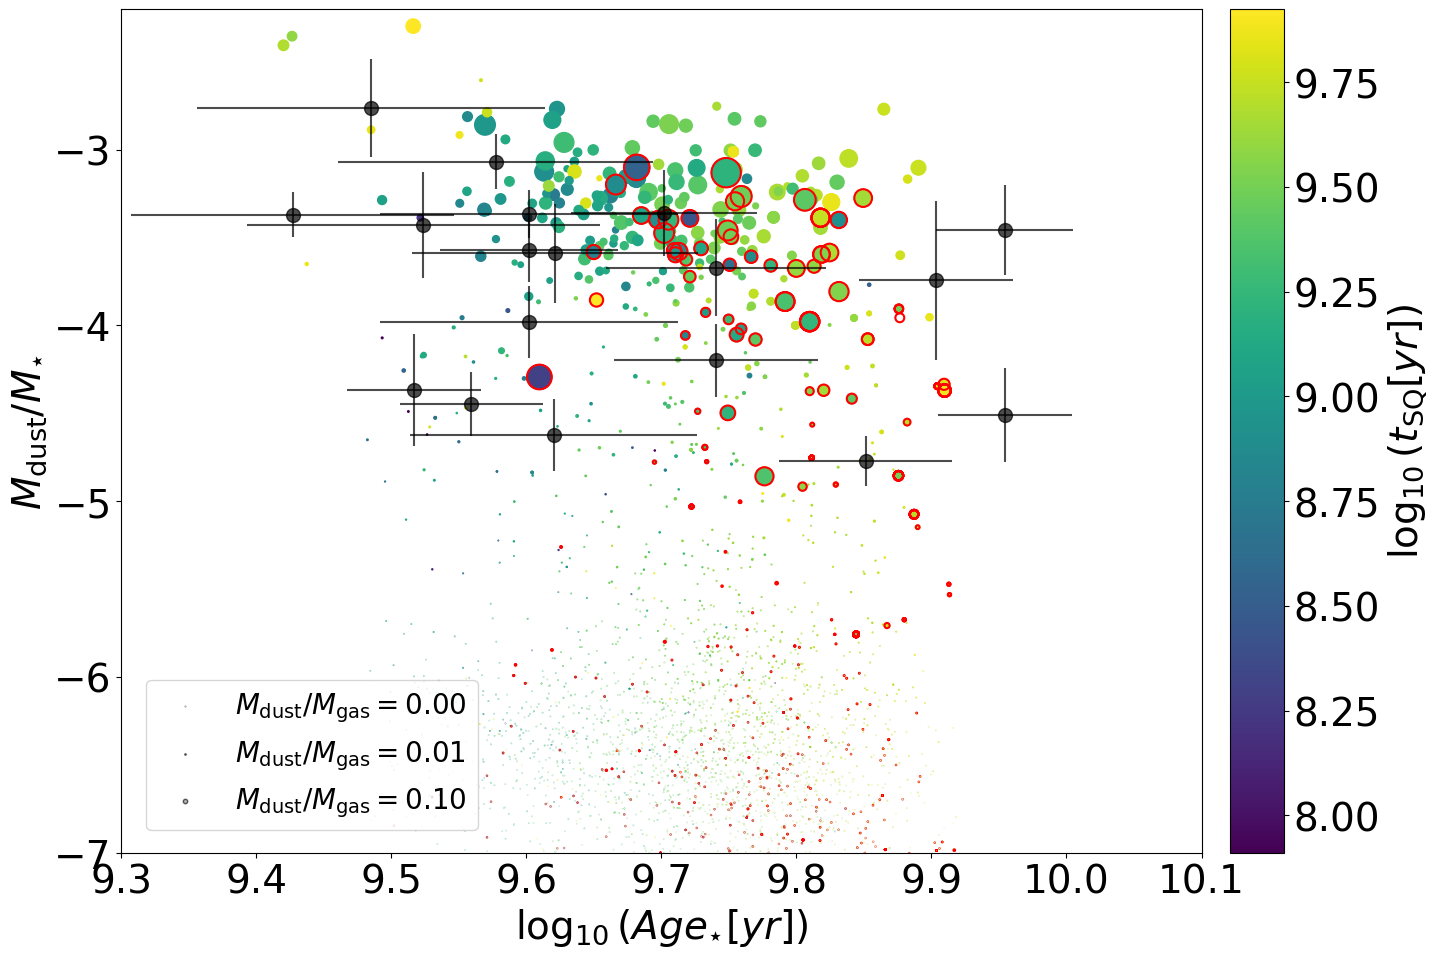

In [72]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np



# Assuming you already have:
# dust, gas, age, tsq, filtid defined
age = np.log10(sfr['mass_weighted_ages'][indx,:]*1e9)  # Assuming this is the correct age array
dust = sfr['dust_masses'][indx,:] / sfr['stellar_masses'][indx,:]  # Dust-to-stellar mass
gas = sfr['H2_masses'][indx,:] / sfr['stellar_masses'][indx,:]     # Gas-to-stellar mass

# Prepare data
x = age[filtid]
y = np.log10(dust[filtid])
c = np.log10(tsq)
s = 300*(dust[filtid] / gas[filtid])  # Size scaling

# Masks for dust/gas ratio
mask_high = 100*gas[filtid] > 1.
mask_low = ~mask_high

print(f'Number of points with gas frac > 1 perc: {len(x[mask_high])}')
print(f'Number of points with gas frac < 1 perc: {len(x[mask_low])}')

# Set up the figure with a GridSpec
fig = plt.figure(figsize=(15, 15))
gs = gridspec.GridSpec(3, 2, width_ratios=[4, 0.2], height_ratios=[0.3, 1, 4],
                       wspace=0.05, hspace=0.05)

# Main scatter plot
ax_main = fig.add_subplot(gs[2, 0])

# Plot high dust/gas points
sc1 = ax_main.scatter(x[mask_high], y[mask_high], c=c[mask_high], s=10*s[mask_high],
                      marker='o')

# Plot low dust/gas points
sc2 = ax_main.scatter(x[mask_low], y[mask_low], c=c[mask_low], s=10*s[mask_low],
                      marker='o')

# Overlay slightly larger red circles for low dust/gas
ax_main.scatter(x[mask_low], y[mask_low], facecolors='none', edgecolors='red',
                s=10*s[mask_low], linewidths=1.5, marker='o')

# Labels and limits
ax_main.set_xlabel(r'$\log_{10}(Age_{\star} [yr])$')
ax_main.set_ylabel(r'$M_{\rm dust}/M_{\star}$')
ax_main.set_ylim(-7, -2.2)
ax_main.set_xlim(9.3, 10.1)

# Characteristic sizes for second legend
example_ratios = [0.001, 0.01, 0.1]  # example dust/gas ratios
example_sizes = [100*r for r in example_ratios]  # match your s = 100*dust/gas, then scaled by 30

handles = [
    plt.scatter([], [], s=sz, edgecolors='k', facecolors='gray', alpha=0.6,
                label=fr'$M_{{\rm dust}}/M_{{\rm gas}} = {r:.2f}$')
    for r, sz in zip(example_ratios, example_sizes)
]

legend2 = ax_main.legend(handles=handles, loc='lower left',
                         bbox_to_anchor=(0.01, 0.01), frameon=True, prop = { "size": 20 }) # add back first legend


# Colorbar
ax_cbar = fig.add_subplot(gs[2, 1])  # right column, main plot height
cbar = plt.colorbar(sc1, cax=ax_cbar, orientation='vertical')
cbar.set_label(r'$\log_{10}(t_{\rm SQ}  [yr])$')




# Load the FITS file
mygals = '/home/lorenzong/ALMA_C11/ALMAC11_sed_ism_modeling_results.fits'
with fits.open(mygals) as hdul:
    hdu = hdul[1].data  
    oage = hdu['Age(log/yr)']
    oage_e = hdu['Age(log/yr)_err']
    odust = hdu['log(Dust_Fraction)']
    odust_e = hdu['log(Dust_Fraction)_err']
    omstar = hdu['log(Mstar/Msol)']
    omstar_e = hdu['logMstar_err']

ax_main.errorbar(oage, odust, 
                 xerr=oage_e, yerr=odust_e, 
                 fmt='o', color='black', markersize=10, 
                 label='Observed Galaxies', alpha=0.7)



plt.savefig(os.path.join(sv.get_filetype_path('plot'), 'dust_age_relation_tsq_036.png'), bbox_inches='tight')

/tmp/ipykernel_218820/2446431429.py:14: RuntimeWarning: divide by zero encountered in log10
  y = np.log10(dust[filtid])
/tmp/ipykernel_218820/2446431429.py:15: RuntimeWarning: invalid value encountered in log10
  c = np.log10(tsq)
/home/lorenzong/.local/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a, func=_nanmedian, axis=axis, out=out,


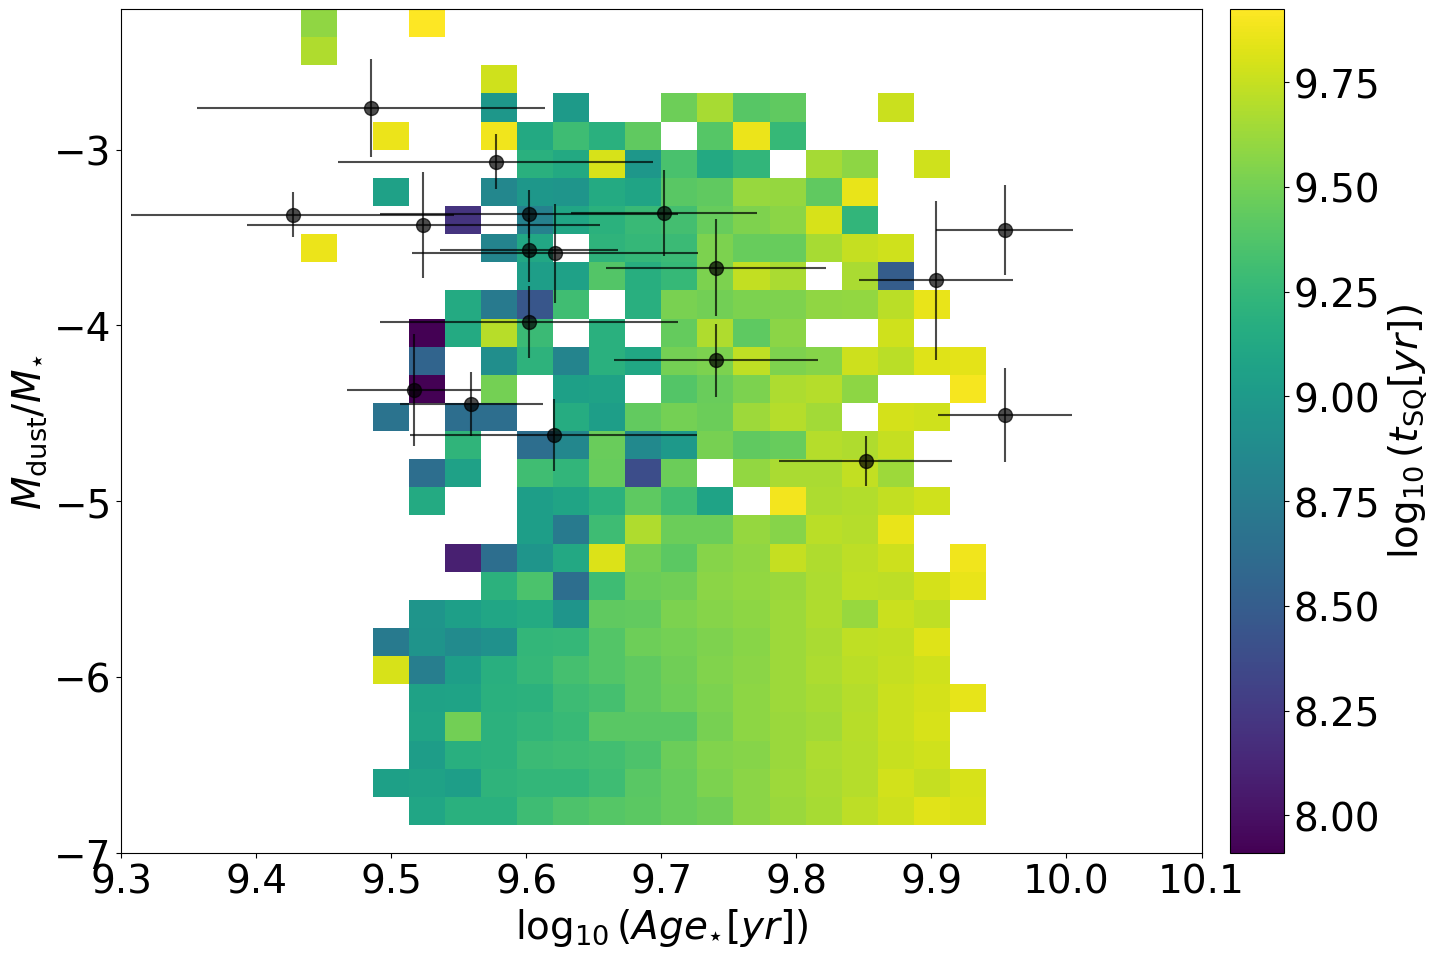

In [95]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import os
from astropy.io import fits

# Calculate necessary quantities
age = np.log10(sfr['mass_weighted_ages'][indx,:]*1e9)
dust = sfr['dust_masses'][indx,:] / sfr['stellar_masses'][indx,:]
gas = sfr['H2_masses'][indx,:] / sfr['stellar_masses'][indx,:]

# Prepare data
x = age[filtid]
y = np.log10(dust[filtid])
c = np.log10(tsq)

# Bin edges
xedges = np.linspace(9.3, 10.1, 30)
yedges = np.linspace(-7, -2.2, 30)

# Digitize x and y
x_bin = np.digitize(x, xedges)
y_bin = np.digitize(y, yedges)

# 2D array to store average c in each bin
heatmap = np.full((len(xedges), len(yedges)), np.nan)

# Fill heatmap
for i in range(1, len(xedges)):
    for j in range(1, len(yedges)):
        mask = (x_bin == i) & (y_bin == j)
        if np.any(mask):
            heatmap[i, j] = np.nanmedian(c[mask])

# Set up the figure
fig = plt.figure(figsize=(15, 15))
gs = gridspec.GridSpec(3, 2, width_ratios=[4, 0.2], height_ratios=[0.3, 1, 4],
                       wspace=0.05, hspace=0.05)

ax_main = fig.add_subplot(gs[2, 0])

# Show heatmap
im = ax_main.imshow(
    heatmap.T,
    origin='lower',
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    aspect='auto',
    cmap='viridis'
)

# Labels and limits
ax_main.set_xlabel(r'$\log_{10}(Age_{\star} [yr])$')
ax_main.set_ylabel(r'$M_{\rm dust}/M_{\star}$')
ax_main.set_xlim(9.3, 10.1)
ax_main.set_ylim(-7, -2.2)

# Colorbar
ax_cbar = fig.add_subplot(gs[2, 1])
cbar = plt.colorbar(im, cax=ax_cbar, orientation='vertical')
cbar.set_label(r'$\log_{10}(t_{\rm SQ}  [yr])$')

# Add observational data
mygals = '/home/lorenzong/ALMA_C11/ALMAC11_sed_ism_modeling_results.fits'
with fits.open(mygals) as hdul:
    hdu = hdul[1].data  
    oage = hdu['Age(log/yr)']
    oage_e = hdu['Age(log/yr)_err']
    odust = hdu['log(Dust_Fraction)']
    odust_e = hdu['log(Dust_Fraction)_err']

ax_main.errorbar(oage, odust, 
                 xerr=oage_e, yerr=odust_e, 
                 fmt='o', color='black', markersize=10, 
                 label='Observed Galaxies', alpha=0.7)

# Save plot
plt.savefig(os.path.join(sv.get_filetype_path('plot'), 'dust_age_relation_grid_tsq_036.png'), bbox_inches='tight')


/tmp/ipykernel_218820/206522907.py:15: RuntimeWarning: divide by zero encountered in log10
  y = np.log10(dust[filtid])
/tmp/ipykernel_218820/206522907.py:16: RuntimeWarning: invalid value encountered in log10
  c = np.log10(tsq)
/tmp/ipykernel_218820/206522907.py:17: RuntimeWarning: divide by zero encountered in divide
  s = 300*(dust[filtid] / gas[filtid])  # Size scaling
/tmp/ipykernel_218820/206522907.py:17: RuntimeWarning: invalid value encountered in divide
  s = 300*(dust[filtid] / gas[filtid])  # Size scaling
/tmp/ipykernel_218820/206522907.py:53: RuntimeWarning: divide by zero encountered in log10
  ax_main.plot(np.log10(sfr['mass_weighted_ages'][:,filtid[i]]*1e9), np.log10(sfr['dust_masses'][:,filtid[i]] / sfr['stellar_masses'][:,filtid[i]]))


Number of points with gas frac > 1 perc: 2530
Number of points with gas frac < 1 perc: 4292


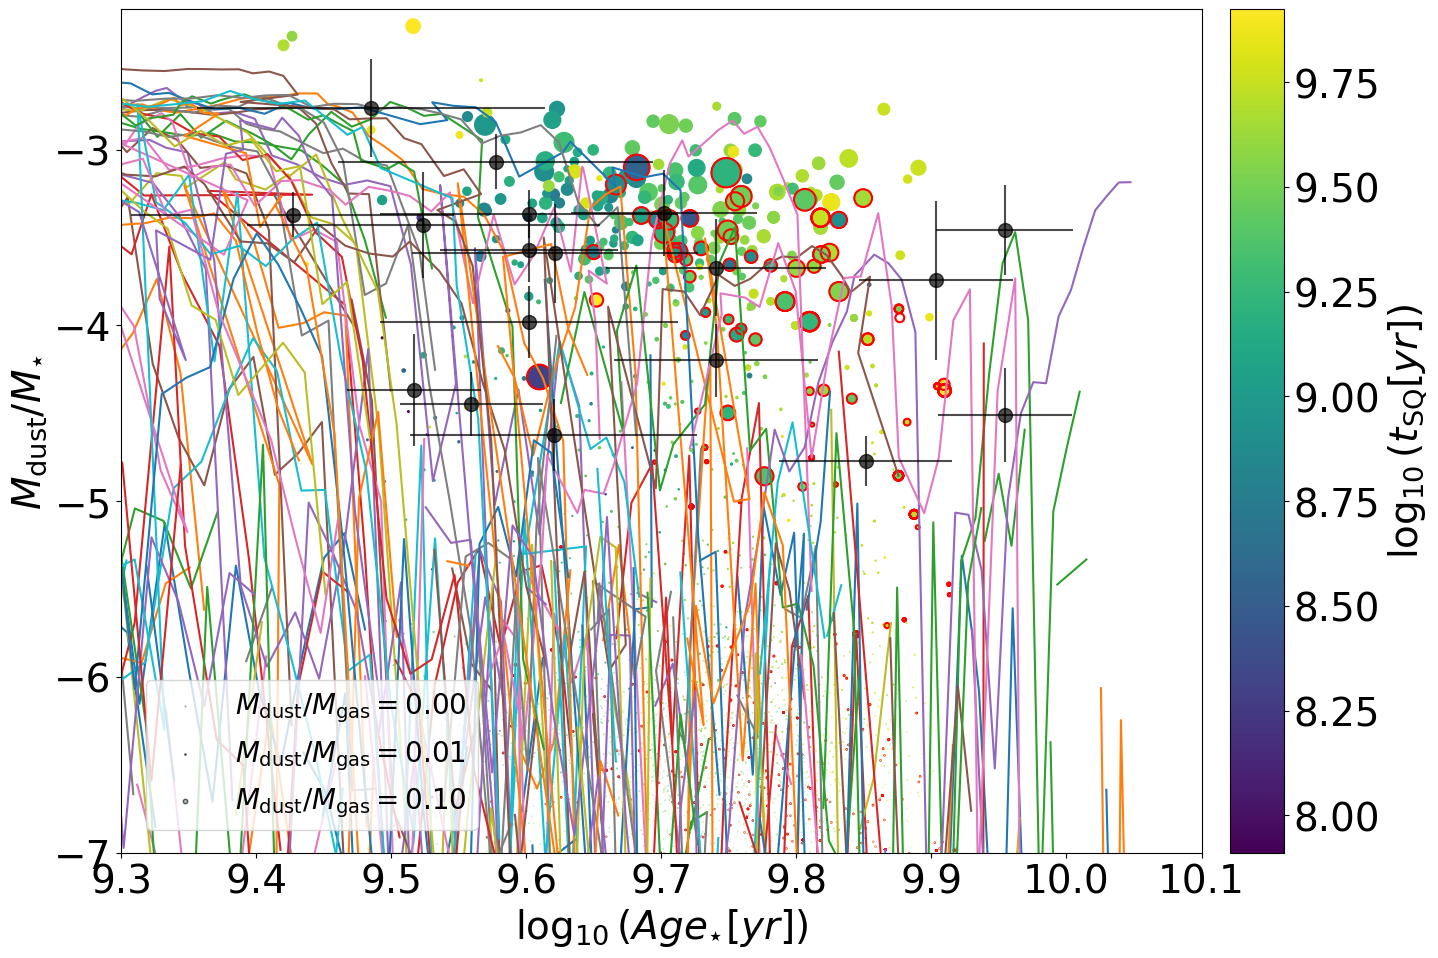

In [78]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np



# Assuming you already have:
# dust, gas, age, tsq, filtid defined
age = np.log10(sfr['mass_weighted_ages'][indx,:]*1e9)  # Assuming this is the correct age array
dust = sfr['dust_masses'][indx,:] / sfr['stellar_masses'][indx,:]  # Dust-to-stellar mass
gas = sfr['H2_masses'][indx,:] / sfr['stellar_masses'][indx,:]     # Gas-to-stellar mass

# Prepare data
x = age[filtid]
y = np.log10(dust[filtid])
c = np.log10(tsq)
s = 300*(dust[filtid] / gas[filtid])  # Size scaling

# Masks for dust/gas ratio
mask_high = 100*gas[filtid] > 1.
mask_low = ~mask_high

print(f'Number of points with gas frac > 1 perc: {len(x[mask_high])}')
print(f'Number of points with gas frac < 1 perc: {len(x[mask_low])}')

# Set up the figure with a GridSpec
fig = plt.figure(figsize=(15, 15))
gs = gridspec.GridSpec(3, 2, width_ratios=[4, 0.2], height_ratios=[0.3, 1, 4],
                       wspace=0.05, hspace=0.05)

# Main scatter plot
ax_main = fig.add_subplot(gs[2, 0])

# Plot high dust/gas points
sc1 = ax_main.scatter(x[mask_high], y[mask_high], c=c[mask_high], s=10*s[mask_high],
                      marker='o')

# Plot low dust/gas points
sc2 = ax_main.scatter(x[mask_low], y[mask_low], c=c[mask_low], s=10*s[mask_low],
                      marker='o')

# Overlay slightly larger red circles for low dust/gas
ax_main.scatter(x[mask_low], y[mask_low], facecolors='none', edgecolors='red',
                s=10*s[mask_low], linewidths=1.5, marker='o')

# Labels and limits
ax_main.set_xlabel(r'$\log_{10}(Age_{\star} [yr])$')
ax_main.set_ylabel(r'$M_{\rm dust}/M_{\star}$')
ax_main.set_ylim(-7, -2.2)
ax_main.set_xlim(9.3, 10.1)

for i in range(50):
    ax_main.plot(np.log10(sfr['mass_weighted_ages'][:,filtid[i]]*1e9), np.log10(sfr['dust_masses'][:,filtid[i]] / sfr['stellar_masses'][:,filtid[i]]))


# Characteristic sizes for second legend
example_ratios = [0.001, 0.01, 0.1]  # example dust/gas ratios
example_sizes = [100*r for r in example_ratios]  # match your s = 100*dust/gas, then scaled by 30

handles = [
    plt.scatter([], [], s=sz, edgecolors='k', facecolors='gray', alpha=0.6,
                label=fr'$M_{{\rm dust}}/M_{{\rm gas}} = {r:.2f}$')
    for r, sz in zip(example_ratios, example_sizes)
]

legend2 = ax_main.legend(handles=handles, loc='lower left',
                         bbox_to_anchor=(0.01, 0.01), frameon=True, prop = { "size": 20 }) # add back first legend


# Colorbar
ax_cbar = fig.add_subplot(gs[2, 1])  # right column, main plot height
cbar = plt.colorbar(sc1, cax=ax_cbar, orientation='vertical')
cbar.set_label(r'$\log_{10}(t_{\rm SQ}  [yr])$')




# Load the FITS file
mygals = '/home/lorenzong/ALMA_C11/ALMAC11_sed_ism_modeling_results.fits'
with fits.open(mygals) as hdul:
    hdu = hdul[1].data  
    oage = hdu['Age(log/yr)']
    oage_e = hdu['Age(log/yr)_err']
    odust = hdu['log(Dust_Fraction)']
    odust_e = hdu['log(Dust_Fraction)_err']
    omstar = hdu['log(Mstar/Msol)']
    omstar_e = hdu['logMstar_err']

ax_main.errorbar(oage, odust, 
                 xerr=oage_e, yerr=odust_e, 
                 fmt='o', color='black', markersize=10, 
                 label='Observed Galaxies', alpha=0.7)



plt.savefig(os.path.join(sv.get_filetype_path('plot'), 'dust_age_relation_tsq_036.png'), bbox_inches='tight')

/tmp/ipykernel_218820/1624605838.py:17: RuntimeWarning: divide by zero encountered in log10
  y = np.log10(dust[filtid])
/tmp/ipykernel_218820/1624605838.py:20: RuntimeWarning: divide by zero encountered in divide
  dgr = dust[filtid] / gas[filtid]
/tmp/ipykernel_218820/1624605838.py:20: RuntimeWarning: invalid value encountered in divide
  dgr = dust[filtid] / gas[filtid]


Points mask1 (DGR>0.05 & 100*gas>1): 291
Points mask2 (DGR>0.05 & 100*gas<=1): 218
Points mask3 (DGR<=0.05 & 100*gas<=1): 3123


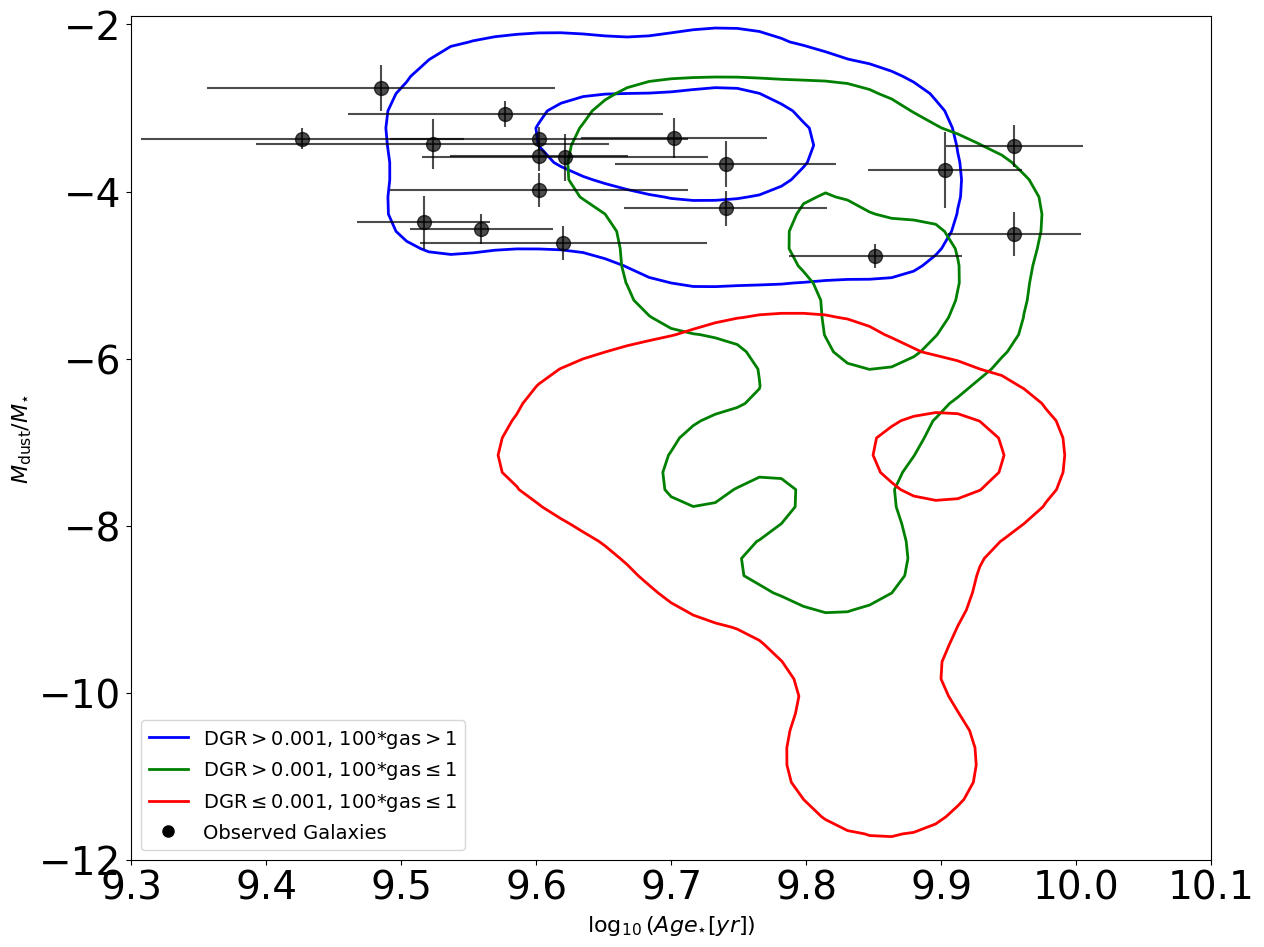

In [73]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from astropy.io import fits
from matplotlib.lines import Line2D

# Assuming your arrays and indices are already defined as:
# sfr, indx, filtid, tsq (from your original context)

# Calculate quantities
age = np.log10(sfr['mass_weighted_ages'][indx, :] * 1e9)  # log age in years
dust = sfr['dust_masses'][indx, :] / sfr['stellar_masses'][indx, :]  # dust-to-stellar mass
gas = sfr['H2_masses'][indx, :] / sfr['stellar_masses'][indx, :]    # gas-to-stellar mass

# Filtered data
x = age[filtid]
y = np.log10(dust[filtid])

# Dust-to-gas ratio (linear)
dgr = dust[filtid] / gas[filtid]

# Define masks
mask1 = (dgr > 0.001) & (100 * gas[filtid] > 1)
mask2 = (dgr > 0.001) & (100 * gas[filtid] <= 1)
mask3 = (dgr <= 0.001) & (100 * gas[filtid] <= 1)

print(f'Points mask1 (DGR>0.05 & 100*gas>1): {np.sum(mask1)}')
print(f'Points mask2 (DGR>0.05 & 100*gas<=1): {np.sum(mask2)}')
print(f'Points mask3 (DGR<=0.05 & 100*gas<=1): {np.sum(mask3)}')

from scipy.ndimage import gaussian_filter

def plot_contour(ax, xdata, ydata, color='blue', levels=3, bins=50, sigma=2.0):
    # Define bins based on axis limits
    xbins = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], bins)
    ybins = np.linspace(ax.get_ylim()[0], ax.get_ylim()[1], bins)

    # Compute 2D histogram
    H, xedges, yedges = np.histogram2d(xdata, ydata, bins=[xbins, ybins])

    # Apply Gaussian smoothing
    H_smooth = gaussian_filter(H, sigma=sigma)

    # Midpoints for plotting
    xcenters = 0.5 * (xedges[1:] + xedges[:-1])
    ycenters = 0.5 * (yedges[1:] + yedges[:-1])

    # Contour levels
    if H_smooth.max() > 0:
        levels_vals = np.linspace(0.05 * H_smooth.max(), H_smooth.max(), levels)
        cont = ax.contour(xcenters, ycenters, H_smooth.T, levels=levels_vals,
                          colors=color, linewidths=2.0)
    else:
        cont = None
    return cont


# Load observed data from FITS file
mygals = '/home/lorenzong/ALMA_C11/ALMAC11_sed_ism_modeling_results.fits'
with fits.open(mygals) as hdul:
    hdu = hdul[1].data
    oage = hdu['Age(log/yr)']
    oage_e = hdu['Age(log/yr)_err']
    odust = hdu['log(Dust_Fraction)']
    odust_e = hdu['log(Dust_Fraction)_err']
    omstar = hdu['log(Mstar/Msol)']
    omstar_e = hdu['logMstar_err']

# Setup figure and grid
fig = plt.figure(figsize=(15, 15))
gs = gridspec.GridSpec(3, 2, width_ratios=[4, 0.2], height_ratios=[0.3, 1, 4],
                       wspace=0.05, hspace=0.05)
ax_main = fig.add_subplot(gs[2, 0])

# Set axis limits before contouring
ax_main.set_xlim(9.3, 10.1)
ax_main.set_ylim(-12, -1.9)

# Plot contours for each mask with distinct colors
plot_contour(ax_main, x[mask1], y[mask1], color='blue')
plot_contour(ax_main, x[mask2], y[mask2], color='green')
plot_contour(ax_main, x[mask3], y[mask3], color='red')

# Plot observed galaxies with error bars
ax_main.errorbar(oage, odust, 
                 xerr=oage_e, yerr=odust_e, 
                 fmt='o', color='black', markersize=10, 
                 label='Observed Galaxies', alpha=0.7)

# Labels
ax_main.set_xlabel(r'$\log_{10}(Age_{\star} [yr])$', fontsize=16)
ax_main.set_ylabel(r'$M_{\rm dust}/M_{\star}$', fontsize=16)

# Legend for contours and observed data
legend_elements = [
    Line2D([0], [0], color='blue', lw=2, label=r'DGR$>0.001$, 100*gas$>1$'),
    Line2D([0], [0], color='green', lw=2, label=r'DGR$>0.001$, 100*gas$\leq 1$'),
    Line2D([0], [0], color='red', lw=2, label=r'DGR$\leq 0.001$, 100*gas$\leq 1$'),
    Line2D([0], [0], marker='o', color='black', label='Observed Galaxies', linestyle='', markersize=8)
]
ax_main.legend(handles=legend_elements, loc='lower left', fontsize=14)

plt.savefig(os.path.join(sv.get_filetype_path('plot'), 'dust_age_relation_contours.png'), bbox_inches='tight')
plt.show()


/tmp/ipykernel_218820/2874064169.py:13: RuntimeWarning: divide by zero encountered in log10
  y = np.log10(dust[filtid])
/tmp/ipykernel_218820/2874064169.py:14: RuntimeWarning: divide by zero encountered in divide
  dgr = dust[filtid] / gas[filtid]
/tmp/ipykernel_218820/2874064169.py:14: RuntimeWarning: invalid value encountered in divide
  dgr = dust[filtid] / gas[filtid]


Region 1: 291 points
Region 2: 218 points
Region 3: 3123 points


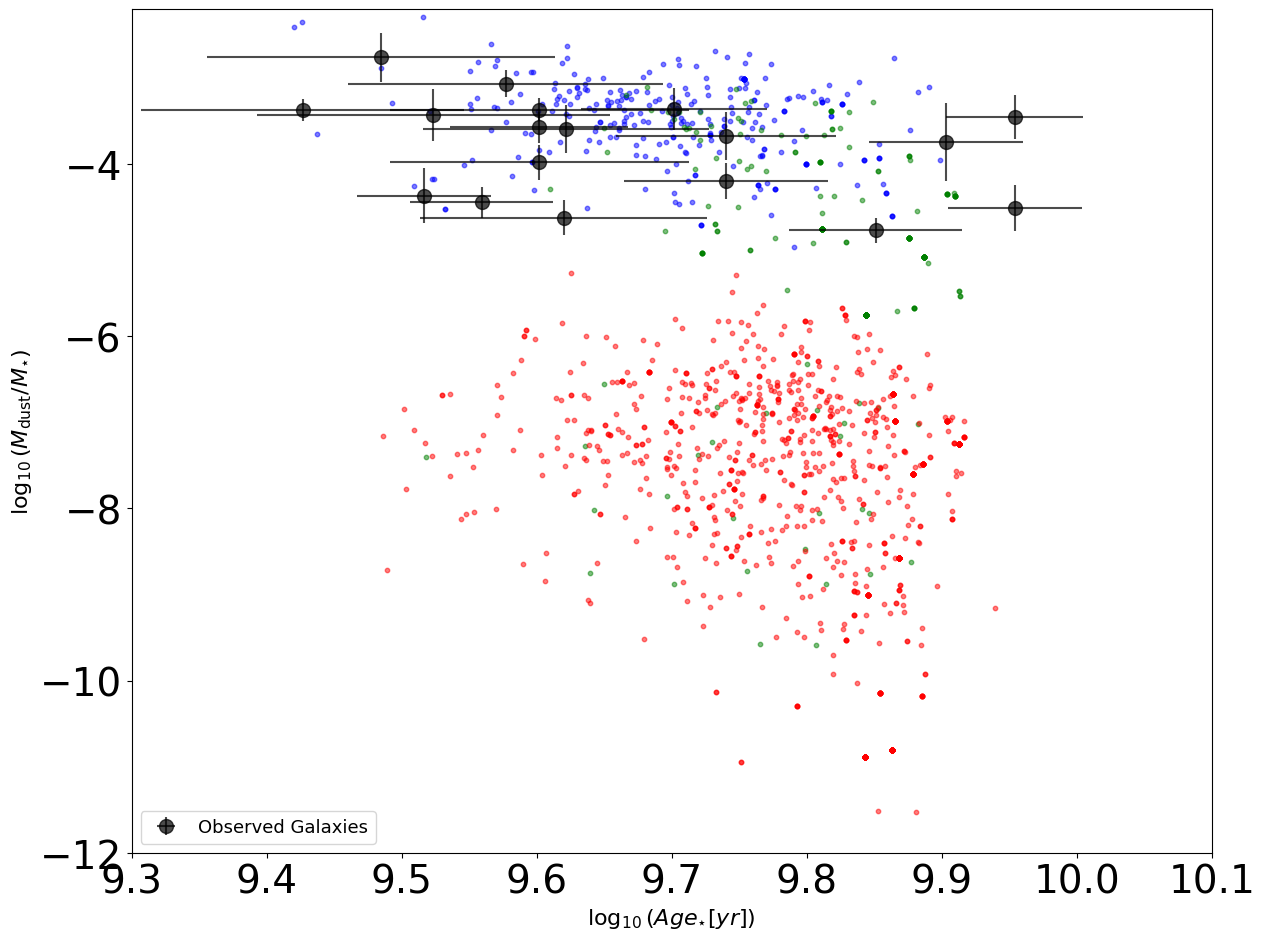

In [61]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from astropy.io import fits
from scipy.optimize import curve_fit

# Prepare simulated data
age = np.log10(sfr['mass_weighted_ages'][indx, :] * 1e9)
dust = sfr['dust_masses'][indx, :] / sfr['stellar_masses'][indx, :]
gas = sfr['H2_masses'][indx, :] / sfr['stellar_masses'][indx, :]

x = age[filtid]
y = np.log10(dust[filtid])
dgr = dust[filtid] / gas[filtid]

# Masks
mask1 = (dgr > 0.001) & (100 * gas[filtid] >= 1)
mask2 = (dgr > 0.001) & (100 * gas[filtid] < 1)
mask3 = (dgr <= 0.001) & (100 * gas[filtid] < 1)

print(f'Region 1: {np.sum(mask1)} points')
print(f'Region 2: {np.sum(mask2)} points')
print(f'Region 3: {np.sum(mask3)} points')

# Exponential model
def exp_model(x, A, B):
    return A * np.exp(B * x)

def double_exp(x, a, b, c, d):
    return a * np.exp(b * x) + c * np.exp(d * x)

# Fit function (works in log space since y is already log10)
def fit_exp_and_plot(ax, xdata, ydata, color, label):
    # Fit the model in linear y space
    try:
        #popt, _ = curve_fit(double_exp, xdata[np.isfinite(ydata)], ydata[np.isfinite(ydata)], maxfev=10000)
        #print(popt)
        #xfit = np.linspace(9.4, 10.1, 200)
        #yfit = double_exp(xfit, *popt)  # plot in log10 space
        #ax.plot(xfit, yfit, color=color, lw=2, label=label + f' (B={popt[1]:.2f})')
        ax.scatter(xdata, ydata, color=color, s=10, alpha=0.5)  # scatter points
        #return popt
    except RuntimeError:
        print(f'Fit failed for {label}')
        return None

# Load observed data
mygals = '/home/lorenzong/ALMA_C11/ALMAC11_sed_ism_modeling_results.fits'
with fits.open(mygals) as hdul:
    hdu = hdul[1].data
    oage = hdu['Age(log/yr)']
    oage_e = hdu['Age(log/yr)_err']
    odust = hdu['log(Dust_Fraction)']
    odust_e = hdu['log(Dust_Fraction)_err']

# Plot setup
fig = plt.figure(figsize=(15, 15))
gs = gridspec.GridSpec(3, 2, width_ratios=[4, 0.2], height_ratios=[0.3, 1, 4],
                       wspace=0.05, hspace=0.05)
ax_main = fig.add_subplot(gs[2, 0])
ax_main.set_xlim(9.3, 10.1)
ax_main.set_ylim(-12, -2.2)

# Fit and plot exponential trends
fit_exp_and_plot(ax_main, x[mask1], y[mask1], color='blue',
                 label=r'DGR$>0.05$, 100$\times$gas$>1$')
fit_exp_and_plot(ax_main, x[mask2], y[mask2], color='green',
                 label=r'DGR$>0.05$, 100$\times$gas$\leq 1$')
fit_exp_and_plot(ax_main, x[mask3], y[mask3], color='red',
                 label=r'DGR$\leq 0.05$, 100$\times$gas$\leq 1$')

# Plot observed galaxies
ax_main.errorbar(oage, odust,
                 xerr=oage_e, yerr=odust_e,
                 fmt='o', color='black', markersize=10,
                 label='Observed Galaxies', alpha=0.7)

# Labels and legend
ax_main.set_xlabel(r'$\log_{10}(Age_{\star} [yr])$', fontsize=16)
ax_main.set_ylabel(r'$\log_{10}(M_{\rm dust}/M_{\star})$', fontsize=16)
ax_main.legend(loc='lower left', fontsize=13, frameon=True)

plt.savefig('dust_age_relation_expfit.png', bbox_inches='tight')
plt.show()


/tmp/ipykernel_218820/870766671.py:15: RuntimeWarning: divide by zero encountered in log10
  y = np.log10(dust[filtid])
/tmp/ipykernel_218820/870766671.py:16: RuntimeWarning: invalid value encountered in log10
  c = np.log10(tsq)
/tmp/ipykernel_218820/870766671.py:17: RuntimeWarning: divide by zero encountered in divide
  s = 300*(dust[filtid] / gas[filtid])
/tmp/ipykernel_218820/870766671.py:17: RuntimeWarning: invalid value encountered in divide
  s = 300*(dust[filtid] / gas[filtid])


Number of points with gas frac > 1 perc: 2547
Number of points with gas frac < 1 perc: 4293


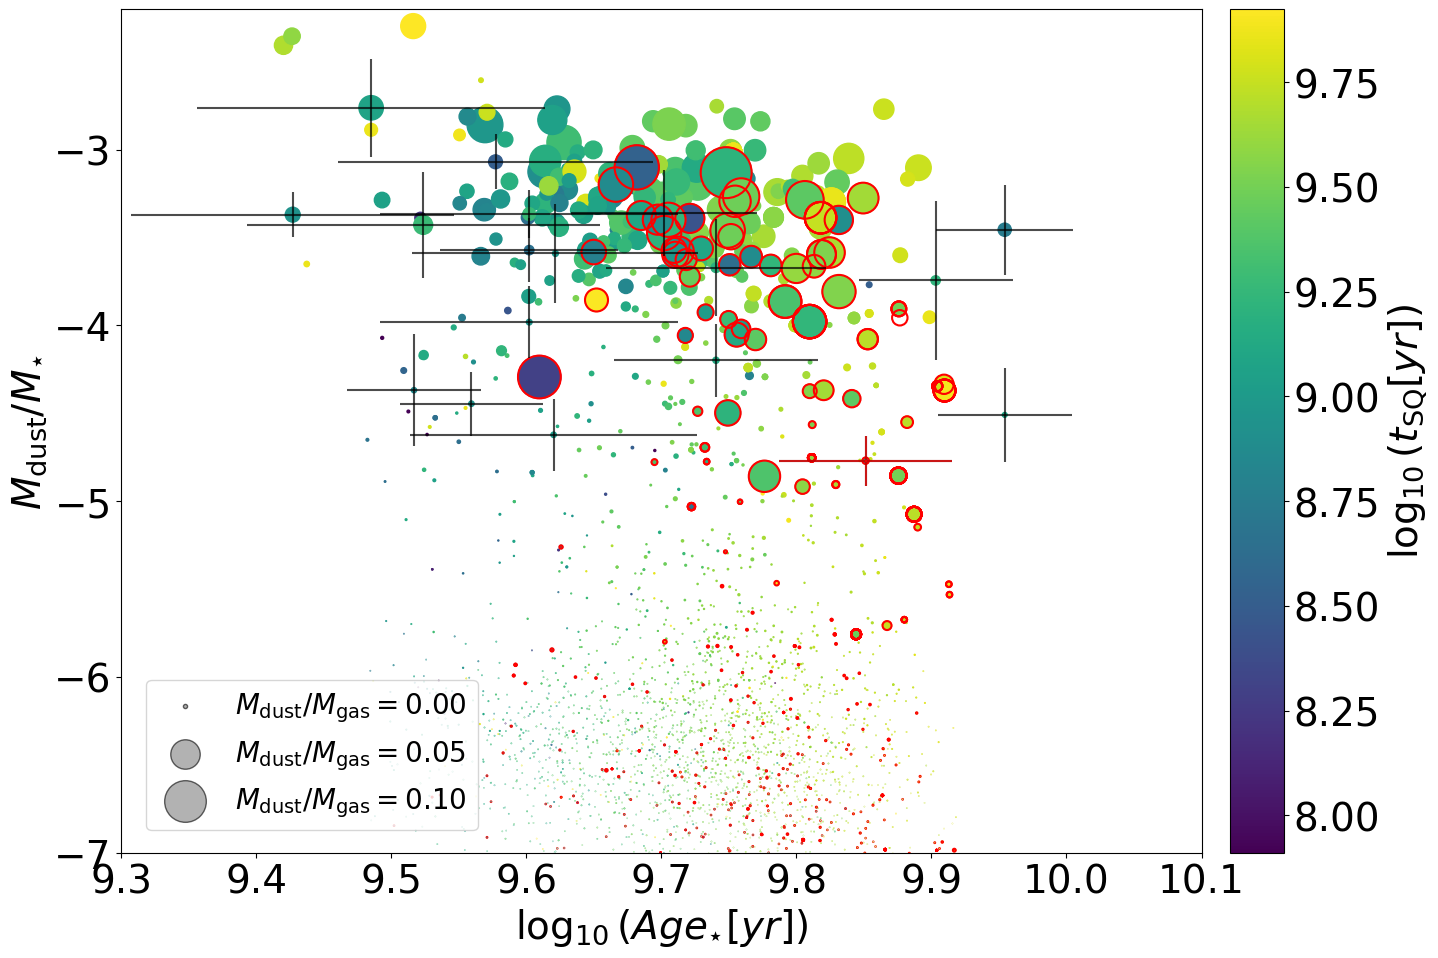

In [21]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np



# Assuming you already have:
# dust, gas, age, tsq, filtid defined
age = np.log10(sfr['mass_weighted_ages'][indx,:]*1e9)  # Assuming this is the correct age array
dust = sfr['dust_masses'][indx,:] / sfr['stellar_masses'][indx,:]  # Dust-to-stellar mass
gas = sfr['H2_masses'][indx,:] / sfr['stellar_masses'][indx,:]     # Gas-to-stellar mass

# Prepare data
x = age[filtid]
y = np.log10(dust[filtid])
c = np.log10(tsq)
s = 300*(dust[filtid] / gas[filtid])  
# Load the FITS file
mygals = '/home/lorenzong/ALMA_C11/ALMAC11_sed_ism_modeling_results.fits'
with fits.open(mygals) as hdul:
    hdu = hdul[1].data  
    oz = hdu['z']
    oage = hdu['Age(log/yr)']
    oage_e = hdu['Age(log/yr)_err']
    odust = hdu['log(Dust_Fraction)']
    odust_e = hdu['log(Dust_Fraction)_err']
    omstar = hdu['log(Mstar/Msol)']
    omstar_e = hdu['logMstar_err']
    otq = np.log10(hdu['tq(Gyr)'] * 1e9)
    ogas = hdu['M_mol [Msun]'] / 10**(omstar)
    odgr = 10**odust / ogas
    s_obs = 300 * odgr

x = np.concatenate((x, oage))
y = np.concatenate((y, odust))
c = np.concatenate((c, otq)) 
s = np.concatenate((s, s_obs))  

mask_high = 100*gas[filtid] > 1.
mask_high = np.concatenate((mask_high, 100*ogas > 1.))
mask_low = ~mask_high

# # Masks for dust/gas ratio
# mask_high = 100*gas[filtid] > 1.
# mask_low = ~mask_high

print(f'Number of points with gas frac > 1 perc: {len(x[mask_high])}')
print(f'Number of points with gas frac < 1 perc: {len(x[mask_low])}')

# Set up the figure with a GridSpec
fig = plt.figure(figsize=(15, 15))
gs = gridspec.GridSpec(3, 2, width_ratios=[4, 0.2], height_ratios=[0.3, 1, 4],
                       wspace=0.05, hspace=0.05)



# Main scatter plot
ax_main = fig.add_subplot(gs[2, 0])

# Plot high dust/gas points
sc1 = ax_main.scatter(x[mask_high], y[mask_high], c=c[mask_high], s=30*s[mask_high],
                      marker='o')

# Plot low dust/gas points
sc2 = ax_main.scatter(x[mask_low], y[mask_low], c=c[mask_low], s=30*s[mask_low],
                      marker='o')

# Overlay slightly larger red circles for low dust/gas
ax_main.scatter(x[mask_low], y[mask_low], facecolors='none', edgecolors='red',
                s=30*s[mask_low], linewidths=1.5, marker='o')

# Labels and limits
ax_main.set_xlabel(r'$\log_{10}(Age_{\star} [yr])$')
ax_main.set_ylabel(r'$M_{\rm dust}/M_{\star}$')
ax_main.set_ylim(-7, -2.2)
ax_main.set_xlim(9.3, 10.1)

# Characteristic sizes for second legend
example_ratios = [0.001, 0.05, 0.1]  # example dust/gas ratios
example_sizes = [30*(300*r) for r in example_ratios]  # match your s = 100*dust/gas, then scaled by 30

handles = [
    plt.scatter([], [], s=sz, edgecolors='k', facecolors='gray', alpha=0.6,
                label=fr'$M_{{\rm dust}}/M_{{\rm gas}} = {r:.2f}$')
    for r, sz in zip(example_ratios, example_sizes)
]

legend2 = ax_main.legend(handles=handles, loc='lower left',
                         bbox_to_anchor=(0.01, 0.01), frameon=True, prop = { "size": 20 }) # add back first legend


# Colorbar
ax_cbar = fig.add_subplot(gs[2, 1])  # right column, main plot height
cbar = plt.colorbar(sc1, cax=ax_cbar, orientation='vertical')
cbar.set_label(r'$\log_{10}(t_{\rm SQ}  [yr])$')






# ax_main.errorbar(oage, odust, 
#                  xerr=oage_e, yerr=odust_e, 
#                  fmt='o', color='k', markersize=10, 
#                  label='Observed Galaxies', alpha=0.7)
ax_main.errorbar(oage, odust, 
                 xerr=oage_e, yerr=odust_e, 
                 fmt='none', ecolor='k', alpha=0.7)

ax_main.errorbar(oage[100*ogas < 1], odust[100*ogas < 1], 
                 xerr=oage_e[100*ogas < 1], yerr=odust_e[100*ogas < 1], 
                 fmt='none', ecolor='r', alpha=0.7)


plt.savefig(os.path.join(sv.get_filetype_path('plot'), 'dust_age_relation_tsq_036.png'), bbox_inches='tight')


/tmp/ipykernel_159580/386780946.py:16: RuntimeWarning: divide by zero encountered in divide
  y = np.log10(dust[filtid] / gas[filtid]) #np.log10(dust[filtid])
/tmp/ipykernel_159580/386780946.py:16: RuntimeWarning: invalid value encountered in divide
  y = np.log10(dust[filtid] / gas[filtid]) #np.log10(dust[filtid])
/tmp/ipykernel_159580/386780946.py:16: RuntimeWarning: divide by zero encountered in log10
  y = np.log10(dust[filtid] / gas[filtid]) #np.log10(dust[filtid])
/tmp/ipykernel_159580/386780946.py:19: RuntimeWarning: divide by zero encountered in divide
  dustgas = np.log10(dust[filtid] / gas[filtid])
/tmp/ipykernel_159580/386780946.py:19: RuntimeWarning: invalid value encountered in divide
  dustgas = np.log10(dust[filtid] / gas[filtid])
/tmp/ipykernel_159580/386780946.py:19: RuntimeWarning: divide by zero encountered in log10
  dustgas = np.log10(dust[filtid] / gas[filtid])


Number of points with dust/gas > -3: 670
Number of points with dust/gas ≤ -3: 7439


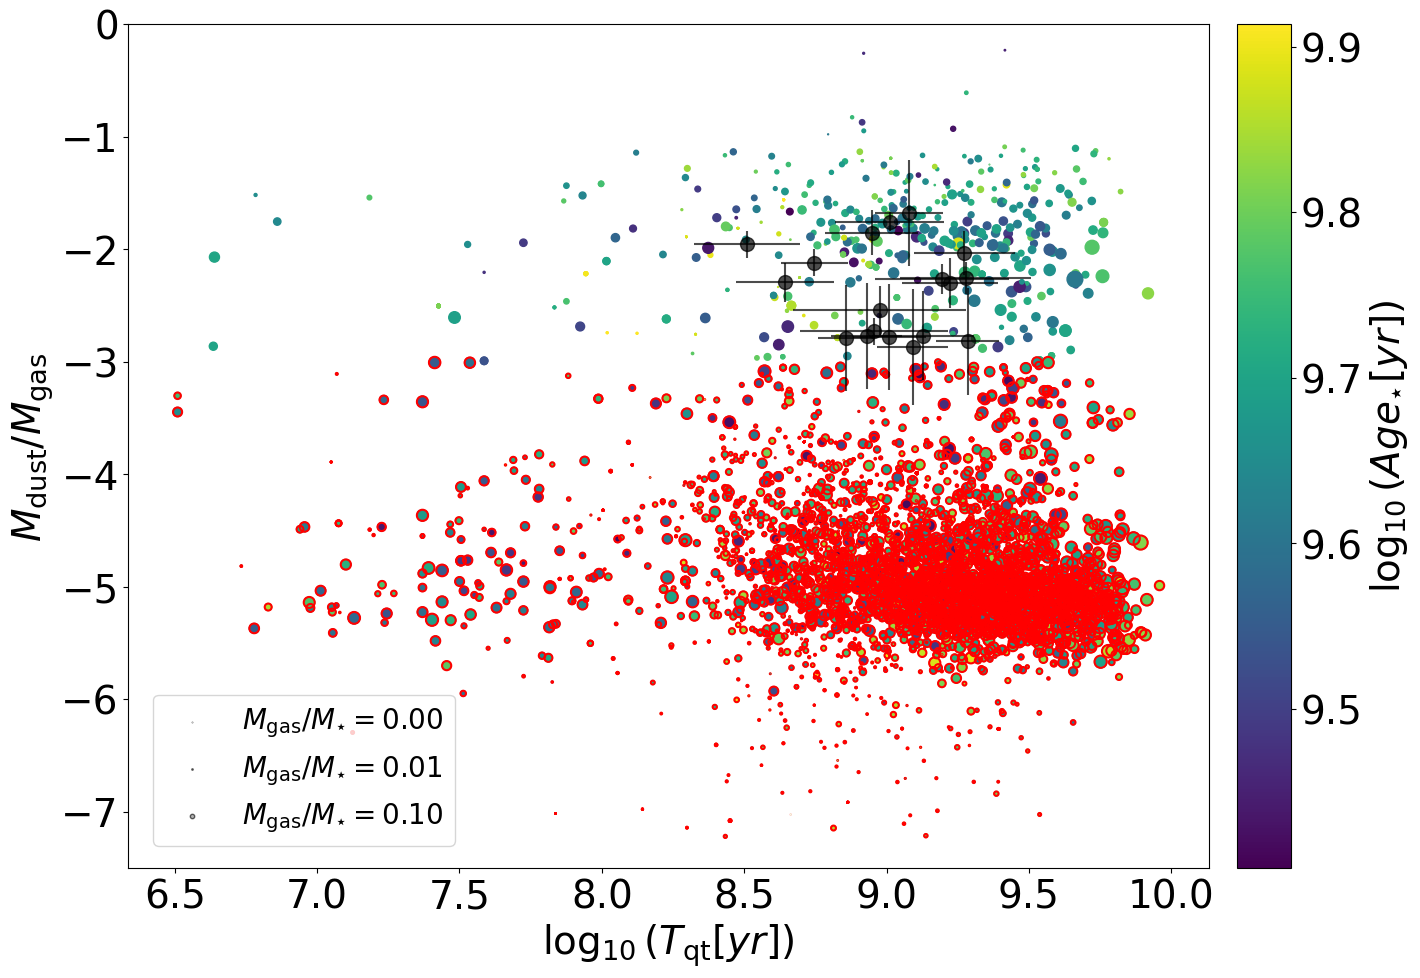

In [192]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np



# Assuming you already have:
# dust, gas, age, tsq, filtid defined
age = np.log10(sfr['mass_weighted_ages'][indx,:]*1e9)  # Assuming this is the correct age array
dust = sfr['dust_masses'][indx,:] / sfr['stellar_masses'][indx,:]  # Dust-to-stellar mass
gas = sfr['H2_masses'][indx,:] / sfr['stellar_masses'][indx,:]     # Gas-to-stellar mass
filtid = galaxy_selection.astype(int)  # Filtered galaxy IDs based on your selection

# Prepare data
c = age[filtid]
y = np.log10(dust[filtid] / gas[filtid]) #np.log10(dust[filtid])
x = np.log10(qt)
s = 100*gas[filtid]  # Size scaling
dustgas = np.log10(dust[filtid] / gas[filtid])

# Masks for dust/gas ratio
mask_high = dustgas > -3
mask_low = ~mask_high

print(f'Number of points with dust/gas > -3: {len(x[mask_high])}')
print(f'Number of points with dust/gas ≤ -3: {len(x[mask_low])}')

# Set up the figure with a GridSpec
fig = plt.figure(figsize=(15, 15))
gs = gridspec.GridSpec(3, 2, width_ratios=[4, 0.2], height_ratios=[0.3, 1, 4],
                       wspace=0.05, hspace=0.05)

# Main scatter plot
ax_main = fig.add_subplot(gs[2, 0])

# Plot high dust/gas points
sc1 = ax_main.scatter(x[mask_high], y[mask_high], c=c[mask_high], s=10*s[mask_high],
                      marker='o')

# Plot low dust/gas points
sc2 = ax_main.scatter(x[mask_low], y[mask_low], c=c[mask_low], s=10*s[mask_low],
                      marker='o')

# Overlay slightly larger red circles for low dust/gas
ax_main.scatter(x[mask_low], y[mask_low], facecolors='none', edgecolors='red',
                s=10*s[mask_low], linewidths=1.5, marker='o')

# Labels and limits
ax_main.set_xlabel(r'$\log_{10}(T_{\rm qt}[yr])$')
ax_main.set_ylabel(r'$M_{\rm dust}/M_{\rm gas}$')
ax_main.set_ylim(-7.5, 0)
#ax_main.set_xlim(9.3, 10.1)

# Characteristic sizes for second legend
example_ratios = [0.001, 0.01, 0.1]  # example dust/gas ratios
example_sizes = [100*r for r in example_ratios]  # match your s = 100*dust/gas, then scaled by 30

handles = [
    plt.scatter([], [], s=sz, edgecolors='k', facecolors='gray', alpha=0.6,
                label=fr'$M_{{\rm gas}}/M_{{\star}} = {r:.2f}$')
    for r, sz in zip(example_ratios, example_sizes)
]

legend2 = ax_main.legend(handles=handles, loc='lower left',
                         bbox_to_anchor=(0.01, 0.01), frameon=True, prop = { "size": 20 }) # add back first legend


# Colorbar
ax_cbar = fig.add_subplot(gs[2, 1])  # right column, main plot height
cbar = plt.colorbar(sc1, cax=ax_cbar, orientation='vertical')
cbar.set_label(r'$\log_{10}(Age_{\star}  [yr])$')




# Load the FITS file
mygals = '/home/lorenzong/ALMA_C11/ALMAC11_sed_ism_modeling_results.fits'
with fits.open(mygals) as hdul:
    hdu = hdul[1].data  
    oage = hdu['Age(log/yr)']
    oage_e = hdu['logAge_err']
    odust = hdu['log(Dust_Fraction)']
    odust_e = hdu['log(Dust_Fraction)_error']
    omstar = hdu['log(Mstar/Msol)']
    omstar_e = hdu['logMstar_err']
    odgr = hdu['logDGR']
    odgr_e = hdu['logDGR_err']
    otq = hdu['tq(Gyr)']
    otq_e = hdu['tq_err(Gyr)']


ax_main.errorbar(np.log10(otq*1e9), odgr, 
                 xerr=otq_e, yerr=odgr_e, 
                 fmt='o', color='black', markersize=10, 
                 label='Observed Galaxies', alpha=0.7)



plt.savefig(os.path.join(sv.get_filetype_path('plot'), 'dgr_qt_relation_age_030.png'), bbox_inches='tight')


In [107]:
age = np.log10(sfr['mass_weighted_ages'][indx,:]*1e9)  # Assuming this is the correct age array
dust = sfr['dust_masses'][indx,:] / sfr['stellar_masses'][indx,:]  # Dust-to-stellar mass
gas = sfr['H2_masses'][indx,:] / sfr['stellar_masses'][indx,:]     # Gas-to-stellar mass


/tmp/ipykernel_159580/3330376233.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  blues = cm.get_cmap('Blues', len(indxes))
/tmp/ipykernel_159580/3330376233.py:6: RuntimeWarning: divide by zero encountered in log10
  y = np.log10(sfr['sfr'][:, i] / sfr['stellar_masses'][:, i])


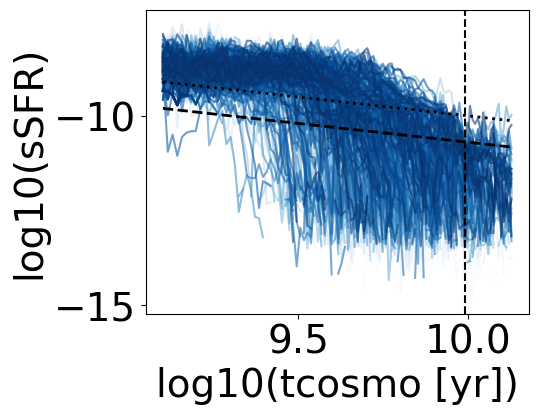

In [124]:
import matplotlib.cm as cm
indxes = galaxy_selection[:500]
blues = cm.get_cmap('Blues', len(indxes))

for j, i in enumerate(indxes):
    y = np.log10(sfr['sfr'][:, i] / sfr['stellar_masses'][:, i])
    y_smooth = y#gaussian_filter1d(y, sigma=sigma, mode='nearest')
    plt.plot(np.log10(tcosmo * 1e9), y_smooth, 
             label=f'{i} {sfr["GroupID"][indx, i]}', 
             color=blues(j), alpha=0.6)
    


plt.plot(np.log10(tcosmo * 1e9), np.log10(1./(tcosmo * 1e9)), 'k:', lw=2, label='1/t')
plt.plot(np.log10(tcosmo * 1e9), np.log10(0.2/(tcosmo * 1e9)), 'k--', lw=2, label='0.2/t')
plt.axvline(np.log10(tcosmo[indx] * 1e9), color='k', ls='--')
#plt.axhline(np.log10(0.2/cosmo.age(z[indx]).to(u.yr).value), color='k', ls=':', lw=2, label='sSFR = 0.2/t')
plt.xlabel('log10(tcosmo [yr])')
plt.ylabel('log10(sSFR)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_159580/2708414277.py:7: RuntimeWarning: divide by zero encountered in log10
  dusty = np.where(np.log10(dust[galaxy_selection]) > -4)[0]
/tmp/ipykernel_159580/2708414277.py:8: RuntimeWarning: divide by zero encountered in log10
  nodust = np.where(np.log10(dust[galaxy_selection]) <= -4)[0]
/tmp/ipykernel_159580/2708414277.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  blues = cm.get_cmap('Blues', len(dusty))
/tmp/ipykernel_159580/2708414277.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  reds = cm.get_cmap('Reds', len(nodust))
/tmp/ipykernel_159580/2708414277.py:20: RuntimeWarning: divide by zero encountered in log10
  y

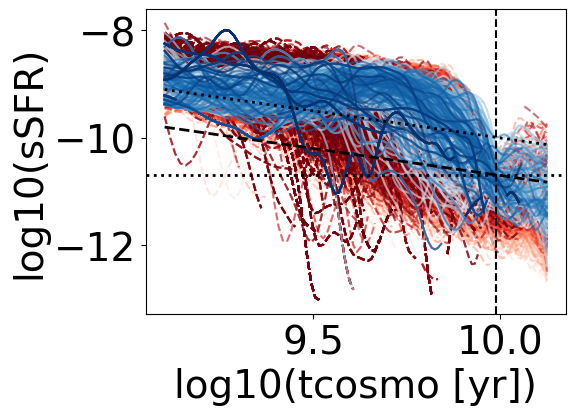

In [126]:
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Setup
dusty = np.where(np.log10(dust[galaxy_selection]) > -4)[0]
nodust = np.where(np.log10(dust[galaxy_selection]) <= -4)[0]

blues = cm.get_cmap('Blues', len(dusty))
reds = cm.get_cmap('Reds', len(nodust))

# Gaussian smoothing parameter
sigma = 2  # adjust for more/less smoothing



# Plot nodust group first (lower zorder)
for j, i in enumerate(nodust):
    y = np.log10(sfr['sfr'][:, galaxy_selection][:, i] / sfr['stellar_masses'][:, galaxy_selection][:, i])
    y_smooth = gaussian_filter1d(y, sigma=sigma, mode='nearest')
    plt.plot(np.log10(tcosmo * 1e9), y_smooth, 
             label=f'{i} {sfr["GroupID"][indx, i]}', 
             color=reds(j), ls='--', alpha=0.6,
             zorder=1)

# Plot dusty group second (higher zorder)
for j, i in enumerate(dusty):
    y = np.log10(sfr['sfr'][:, galaxy_selection][:, i] / sfr['stellar_masses'][:, galaxy_selection][:, i])
    y_smooth = gaussian_filter1d(y, sigma=sigma, mode='nearest')
    plt.plot(np.log10(tcosmo * 1e9), y_smooth, 
             label=f'{i} {sfr["GroupID"][indx, i]}', 
             color=blues(j), alpha=0.6,
             zorder=2)


plt.plot(np.log10(tcosmo * 1e9), np.log10(1./(tcosmo * 1e9)), 'k:', lw=2, label='1/t')
plt.plot(np.log10(tcosmo * 1e9), np.log10(0.2/(tcosmo * 1e9)), 'k--', lw=2, label='0.2/t')
plt.axvline(np.log10(tcosmo[indx] * 1e9), color='k', ls='--')
plt.axhline(np.log10(0.2/cosmo.age(z[indx]).to(u.yr).value), color='k', ls=':', lw=2, label='sSFR = 0.2/t')
plt.xlabel('log10(tcosmo [yr])')
plt.ylabel('log10(sSFR)')
plt.tight_layout()
plt.show()


/tmp/ipykernel_199141/980697845.py:1: RuntimeWarning: divide by zero encountered in log10
  dusty = np.where(np.log10(dust[galaxy_selection]) > -4)[0]
/tmp/ipykernel_199141/980697845.py:2: RuntimeWarning: divide by zero encountered in log10
  nodust = np.where(np.log10(dust[galaxy_selection]) <= -4)[0]


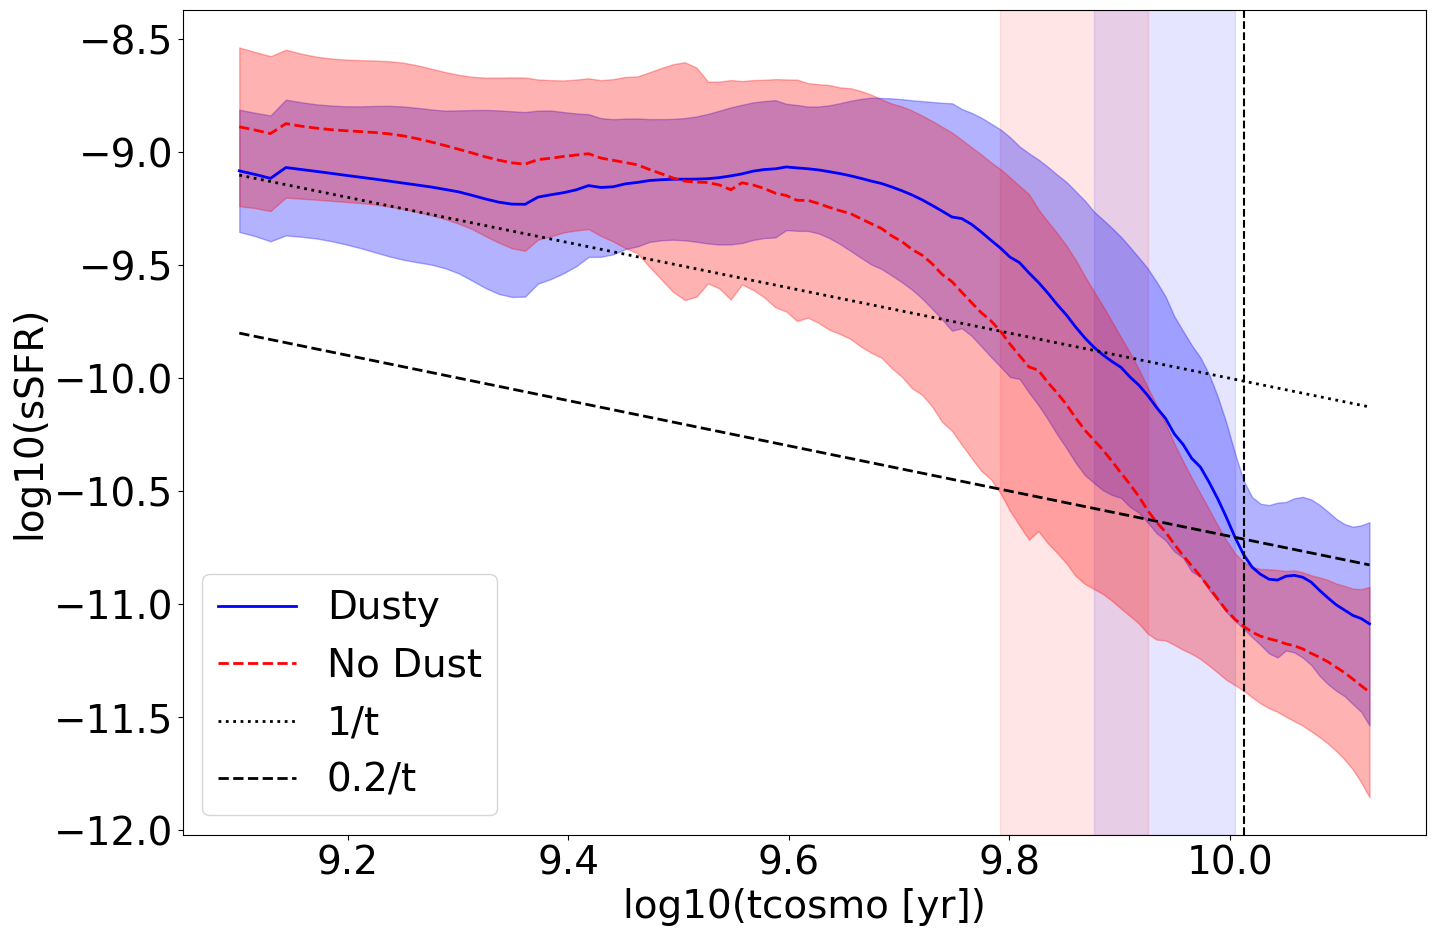

In [36]:
dusty = np.where(np.log10(dust[galaxy_selection]) > -4)[0]
nodust = np.where(np.log10(dust[galaxy_selection]) <= -4)[0]
# dusty = np.where(np.log10(dust[filtid] / gas[filtid]) > -2)[0]
# nodust = np.where(np.log10(dust[filtid] / gas[filtid]) <= -2)[0]

sigma = 2

# Time axis
log_t = np.log10(tcosmo * 1e9)  # log10 of cosmic time in years
nt = len(log_t)

# Initialize arrays to store smoothed log sSFR histories
dusty_sfrs = []
nodust_sfrs = []

for i in dusty:
    sfr_vals = sfr['sfr'][:, galaxy_selection][:, i]
    mass_vals = sfr['stellar_masses'][:, galaxy_selection][:, i]
    
    with np.errstate(divide='ignore', invalid='ignore'):
        ssfr = sfr_vals / mass_vals
        log_ssfr = np.log10(ssfr)
        log_ssfr[~np.isfinite(log_ssfr)] = np.nan  # Replace inf/-inf/nan with nan
        
    y_smooth = gaussian_filter1d(log_ssfr, sigma=sigma, mode='nearest')
    dusty_sfrs.append(y_smooth)

# Same for nodust galaxies (red)
for i in nodust:
    sfr_vals = sfr['sfr'][:, galaxy_selection][:, i]
    mass_vals = sfr['stellar_masses'][:, galaxy_selection][:, i]
    
    with np.errstate(divide='ignore', invalid='ignore'):
        ssfr = sfr_vals / mass_vals
        log_ssfr = np.log10(ssfr)
        log_ssfr[~np.isfinite(log_ssfr)] = np.nan
        
    y_smooth = gaussian_filter1d(log_ssfr, sigma=sigma, mode='nearest')
    nodust_sfrs.append(y_smooth)

# Convert to arrays
dusty_sfrs = np.array(dusty_sfrs).T  # shape: (Ndusty, nt)
nodust_sfrs = np.array(nodust_sfrs).T  # shape: (Nnodust, nt)

# Compute mean and std
dusty_mean = np.nanmean(dusty_sfrs, axis=1)
dusty_std = np.nanstd(dusty_sfrs, axis=1)

nodust_mean = np.nanmean(nodust_sfrs, axis=1)
nodust_std = np.nanstd(nodust_sfrs, axis=1)


eqd, sqd = findQT(10**(log_t), dusty_mean, plot = False)
eqn, sqn = findQT(10**(log_t), nodust_mean, plot = False)

# Plot
plt.figure(figsize=(15, 10))

# Dusty group (blue)
plt.plot(log_t, dusty_mean, color='blue', label='Dusty', lw=2)
plt.fill_between(log_t, dusty_mean - dusty_std, dusty_mean + dusty_std,
                 color='blue', alpha=0.3)

# Nodust group (red)
plt.plot(log_t, nodust_mean, color='red', ls='--', label='No Dust', lw=2)
plt.fill_between(log_t, nodust_mean - nodust_std, nodust_mean + nodust_std,
                 color='red', alpha=0.3)

# Reference lines
plt.plot(log_t, np.log10(1./(tcosmo * 1e9)), 'k:', lw=2, label='1/t')
plt.plot(log_t, np.log10(0.2/(tcosmo * 1e9)), 'k--', lw=2, label='0.2/t')
plt.axvline(np.log10(tcosmo[indx] * 1e9), color='k', ls='--')

plt.axvspan(np.log10(sqd), np.log10(eqd), color='blue', alpha=0.1, zorder=0)
plt.axvspan(np.log10(sqn), np.log10(eqn), color='red', alpha=0.1, zorder=0)

# Labels and legend
plt.xlabel('log10(tcosmo [yr])')
plt.ylabel('log10(sSFR)')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(sv.get_filetype_path('plot'), 'dusty_nodust_sSFR_histories_dustmass.png'), bbox_inches='tight')


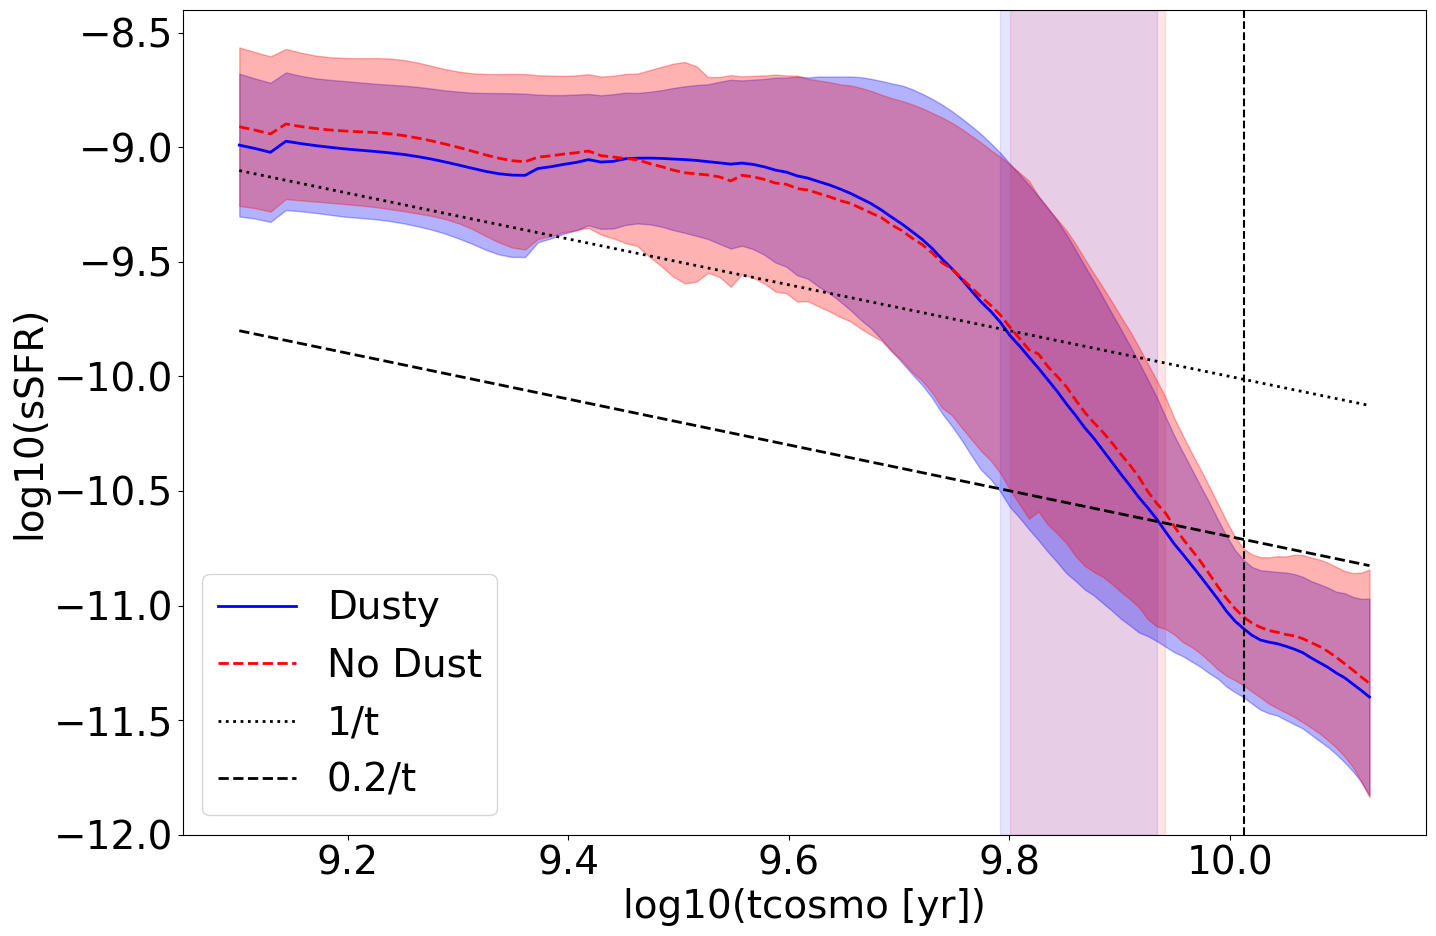

In [38]:
dusty = np.where(gas[filtid]*100 > 1)[0]
nodust = np.where(gas[filtid]*100 <= 1)[0]
# dusty = np.where(np.log10(dust[filtid] / gas[filtid]) > -2)[0]
# nodust = np.where(np.log10(dust[filtid] / gas[filtid]) <= -2)[0]

sigma = 2

# Time axis
log_t = np.log10(tcosmo * 1e9)  # log10 of cosmic time in years
nt = len(log_t)

# Initialize arrays to store smoothed log sSFR histories
dusty_sfrs = []
nodust_sfrs = []

for i in dusty:
    sfr_vals = sfr['sfr'][:, galaxy_selection][:, i]
    mass_vals = sfr['stellar_masses'][:, galaxy_selection][:, i]
    
    with np.errstate(divide='ignore', invalid='ignore'):
        ssfr = sfr_vals / mass_vals
        log_ssfr = np.log10(ssfr)
        log_ssfr[~np.isfinite(log_ssfr)] = np.nan  # Replace inf/-inf/nan with nan
        
    y_smooth = gaussian_filter1d(log_ssfr, sigma=sigma, mode='nearest')
    dusty_sfrs.append(y_smooth)

# Same for nodust galaxies (red)
for i in nodust:
    sfr_vals = sfr['sfr'][:, galaxy_selection][:, i]
    mass_vals = sfr['stellar_masses'][:, galaxy_selection][:, i]
    
    with np.errstate(divide='ignore', invalid='ignore'):
        ssfr = sfr_vals / mass_vals
        log_ssfr = np.log10(ssfr)
        log_ssfr[~np.isfinite(log_ssfr)] = np.nan
        
    y_smooth = gaussian_filter1d(log_ssfr, sigma=sigma, mode='nearest')
    nodust_sfrs.append(y_smooth)

# Convert to arrays
dusty_sfrs = np.array(dusty_sfrs).T  # shape: (Ndusty, nt)
nodust_sfrs = np.array(nodust_sfrs).T  # shape: (Nnodust, nt)

# Compute mean and std
dusty_mean = np.nanmean(dusty_sfrs, axis=1)
dusty_std = np.nanstd(dusty_sfrs, axis=1)

nodust_mean = np.nanmean(nodust_sfrs, axis=1)
nodust_std = np.nanstd(nodust_sfrs, axis=1)


eqd, sqd = findQT(10**(log_t), dusty_mean, plot = False)
eqn, sqn = findQT(10**(log_t), nodust_mean, plot = False)

# Plot
plt.figure(figsize=(15, 10))

# Dusty group (blue)
plt.plot(log_t, dusty_mean, color='blue', label='Dusty', lw=2)
plt.fill_between(log_t, dusty_mean - dusty_std, dusty_mean + dusty_std,
                 color='blue', alpha=0.3)

# Nodust group (red)
plt.plot(log_t, nodust_mean, color='red', ls='--', label='No Dust', lw=2)
plt.fill_between(log_t, nodust_mean - nodust_std, nodust_mean + nodust_std,
                 color='red', alpha=0.3)

# Reference lines
plt.plot(log_t, np.log10(1./(tcosmo * 1e9)), 'k:', lw=2, label='1/t')
plt.plot(log_t, np.log10(0.2/(tcosmo * 1e9)), 'k--', lw=2, label='0.2/t')
plt.axvline(np.log10(tcosmo[indx] * 1e9), color='k', ls='--')

plt.axvspan(np.log10(sqd), np.log10(eqd), color='blue', alpha=0.1, zorder=0)
plt.axvspan(np.log10(sqn), np.log10(eqn), color='red', alpha=0.1, zorder=0)

# Labels and legend
plt.xlabel('log10(tcosmo [yr])')
plt.ylabel('log10(sSFR)')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(sv.get_filetype_path('plot'), 'dusty_nodust_sSFR_histories_gasmass.png'), bbox_inches='tight')


/tmp/ipykernel_199141/161136295.py:1: RuntimeWarning: divide by zero encountered in divide
  dusty = np.where(np.log10(dust[filtid] / gas[filtid]) > -2)[0]
/tmp/ipykernel_199141/161136295.py:1: RuntimeWarning: invalid value encountered in divide
  dusty = np.where(np.log10(dust[filtid] / gas[filtid]) > -2)[0]
/tmp/ipykernel_199141/161136295.py:1: RuntimeWarning: divide by zero encountered in log10
  dusty = np.where(np.log10(dust[filtid] / gas[filtid]) > -2)[0]
/tmp/ipykernel_199141/161136295.py:2: RuntimeWarning: divide by zero encountered in divide
  nodust = np.where(np.log10(dust[filtid] / gas[filtid]) <= -2)[0]
/tmp/ipykernel_199141/161136295.py:2: RuntimeWarning: invalid value encountered in divide
  nodust = np.where(np.log10(dust[filtid] / gas[filtid]) <= -2)[0]
/tmp/ipykernel_199141/161136295.py:2: RuntimeWarning: divide by zero encountered in log10
  nodust = np.where(np.log10(dust[filtid] / gas[filtid]) <= -2)[0]


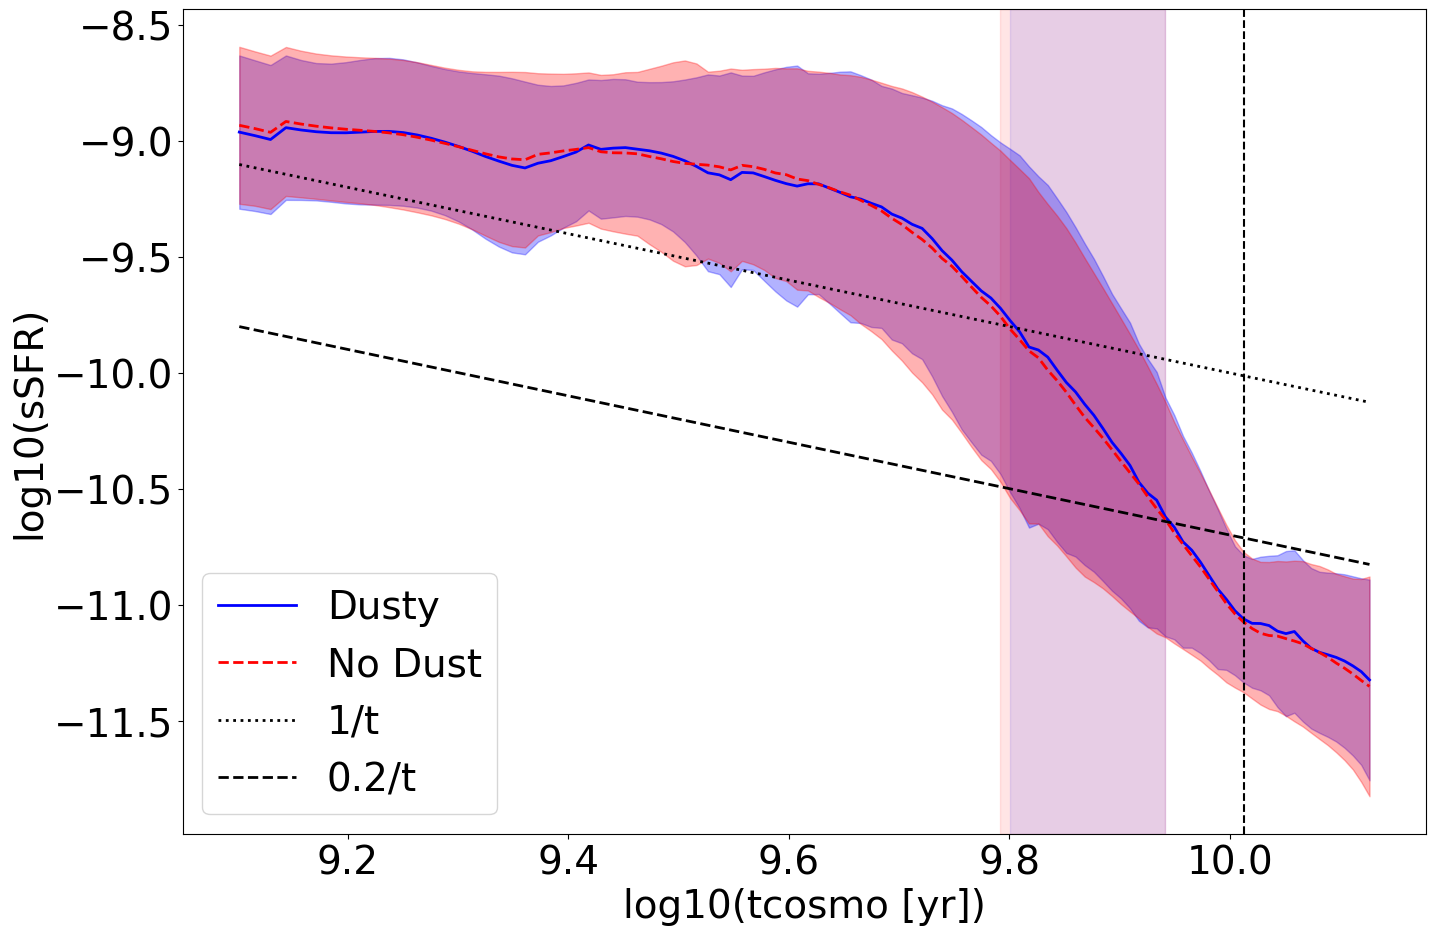

In [39]:

dusty = np.where(np.log10(dust[filtid] / gas[filtid]) > -2)[0]
nodust = np.where(np.log10(dust[filtid] / gas[filtid]) <= -2)[0]

sigma = 2

# Time axis
log_t = np.log10(tcosmo * 1e9)  # log10 of cosmic time in years
nt = len(log_t)

# Initialize arrays to store smoothed log sSFR histories
dusty_sfrs = []
nodust_sfrs = []

for i in dusty:
    sfr_vals = sfr['sfr'][:, galaxy_selection][:, i]
    mass_vals = sfr['stellar_masses'][:, galaxy_selection][:, i]
    
    with np.errstate(divide='ignore', invalid='ignore'):
        ssfr = sfr_vals / mass_vals
        log_ssfr = np.log10(ssfr)
        log_ssfr[~np.isfinite(log_ssfr)] = np.nan  # Replace inf/-inf/nan with nan
        
    y_smooth = gaussian_filter1d(log_ssfr, sigma=sigma, mode='nearest')
    dusty_sfrs.append(y_smooth)

# Same for nodust galaxies (red)
for i in nodust:
    sfr_vals = sfr['sfr'][:, galaxy_selection][:, i]
    mass_vals = sfr['stellar_masses'][:, galaxy_selection][:, i]
    
    with np.errstate(divide='ignore', invalid='ignore'):
        ssfr = sfr_vals / mass_vals
        log_ssfr = np.log10(ssfr)
        log_ssfr[~np.isfinite(log_ssfr)] = np.nan
        
    y_smooth = gaussian_filter1d(log_ssfr, sigma=sigma, mode='nearest')
    nodust_sfrs.append(y_smooth)

# Convert to arrays
dusty_sfrs = np.array(dusty_sfrs).T  # shape: (Ndusty, nt)
nodust_sfrs = np.array(nodust_sfrs).T  # shape: (Nnodust, nt)

# Compute mean and std
dusty_mean = np.nanmean(dusty_sfrs, axis=1)
dusty_std = np.nanstd(dusty_sfrs, axis=1)

nodust_mean = np.nanmean(nodust_sfrs, axis=1)
nodust_std = np.nanstd(nodust_sfrs, axis=1)


eqd, sqd = findQT(10**(log_t), dusty_mean, plot = False)
eqn, sqn = findQT(10**(log_t), nodust_mean, plot = False)

# Plot
plt.figure(figsize=(15, 10))

# Dusty group (blue)
plt.plot(log_t, dusty_mean, color='blue', label='Dusty', lw=2)
plt.fill_between(log_t, dusty_mean - dusty_std, dusty_mean + dusty_std,
                 color='blue', alpha=0.3)

# Nodust group (red)
plt.plot(log_t, nodust_mean, color='red', ls='--', label='No Dust', lw=2)
plt.fill_between(log_t, nodust_mean - nodust_std, nodust_mean + nodust_std,
                 color='red', alpha=0.3)

# Reference lines
plt.plot(log_t, np.log10(1./(tcosmo * 1e9)), 'k:', lw=2, label='1/t')
plt.plot(log_t, np.log10(0.2/(tcosmo * 1e9)), 'k--', lw=2, label='0.2/t')
plt.axvline(np.log10(tcosmo[indx] * 1e9), color='k', ls='--')

plt.axvspan(np.log10(sqd), np.log10(eqd), color='blue', alpha=0.1, zorder=0)
plt.axvspan(np.log10(sqn), np.log10(eqn), color='red', alpha=0.1, zorder=0)

# Labels and legend
plt.xlabel('log10(tcosmo [yr])')
plt.ylabel('log10(sSFR)')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(sv.get_filetype_path('plot'), 'dusty_nodust_sSFR_histories_gasmass.png'), bbox_inches='tight')


In [187]:
eqd, sqd = findQT(10**(log_t), dusty_mean, plot = False)
eqn, sqn = findQT(10**(log_t), nodust_mean, plot = False)
print('Quenching time for dusty galaxies:', (eqd-sqd)/1e9, ' Gyr]')
print('Quenching time for no dust galaxies:', (eqn-sqn)/1e9, ' [Gyr]')

Quenching time for dusty galaxies: 2.8149651672988845  Gyr]
Quenching time for no dust galaxies: 2.37974742550191  [Gyr]
